<a href="https://colab.research.google.com/github/vishal-suri/ExData_Plotting1/blob/master/EasyVisa_Vishal_Suri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 sklearn-pandas==2.2.0 xgboost==3.0.5 imbalanced-learn -q --user


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 9.3 MB/s eta 0:00:00


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [143]:
# Import all the necessary libraries
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [3]:
# Loading the dataset
easyvisa = pd.read_csv("EasyVisa.csv")

In [4]:
# Checking the number of rows and columns in the data
easyvisa.shape

(25480, 12)

# **Overview of the Dataset**

In [5]:
#Make a copy of the dataset
data = easyvisa.copy()

In [6]:
# First 5 rows of the data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [7]:
# Last 5 rows of the data
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [8]:
# The data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


##Observations
1. Many of the columns in this case are categorical variables : Continent, Education, Job Experience, Training Required, Region of Employment, Wage Unit, Fulltime POsition and even the final decision flag all need to be converted from object to categorical variables.
2. Even number of employees, year of establishment, and prevailing wage can potentially be converted to their quartiles and then converted to categorical variables.  Let us investigate that later in the code.
3. There do not seem to be any null values in the dataset.  Let us confirm that later as well.


In [9]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

##Observations
1. No duplicate entries in the dataset.

In [10]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
case_id,0.000
continent,0.000
education_of_employee,0.000
has_job_experience,0.000
requires_job_training,0.000
no_of_employees,0.000
yr_of_estab,0.000
region_of_employment,0.000
prevailing_wage,0.000
unit_of_wage,0.000


##Observations
1. No null value entries in the dataset.

In [11]:
#Check the number of unique values in each column
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


##Observations
1. Except for number of employees, years of establishment, and prevailing wage, all variables can be converted to categorical variables.

In [12]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


##Observations
1. Number of employees can be converted to its quartiles - Less than 1000 employees, 1000-2100 employees, 2100-3500 employees, or more than 3500 employees
2. Year of establishment can be converted to the following quartiles : Established before 1976, between 1977-1997, between 1998-2005, or after 2005.
3. Prevailing wage can be converted to the following quartiles : Prevailing wage less than 34,000; between 34,000-70,000; between 70,000-108,000; or more than 108,000.
We will see during the code which of these makes sense to convert to categorical variables also.
4.  **However, this conversion should be done after splitting train, validation, test, as otherwise there will be data leakage from test and validation data into training data**

In [13]:
# Making a list of all variables that should be categorical and not of type object
cat_col = [
    "continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position",
    "case_status"
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
----------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
----------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
----------------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
--------

##Observations
1. About 70% of the applicants are from Asia, followed by about 12% each from Europe and North America.  Applications from South America, Africa, and Oceania are much fewer.
2. About 40% of the applicants are Bachelor's degree holders, while 35% are Master's.  Only about 15% and 10% of the applicants are high school and Doctorate degree holders.
3. About 60% of the applicants have job experience while 40% do not.
4. About 87% of the applicants do not require job training.
5. Region of employment is roughly equally split between North-East, South, and West; while MidWest and Island combine to form roughly similar requirement.
6. Over 85% of the wages have been expressed in yearly terms
7. Over 85% of the positions are full-time, while the rest are part-time
8. About 33% of the applicants were denied visa, showing imbalance in the eventual decision flag.


In [14]:
# Convert all data that should definitely be categorical to categorical
for col in cat_col:
  data[col] = data[col].astype("category")

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

##**Univariate Analysis**

In [15]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

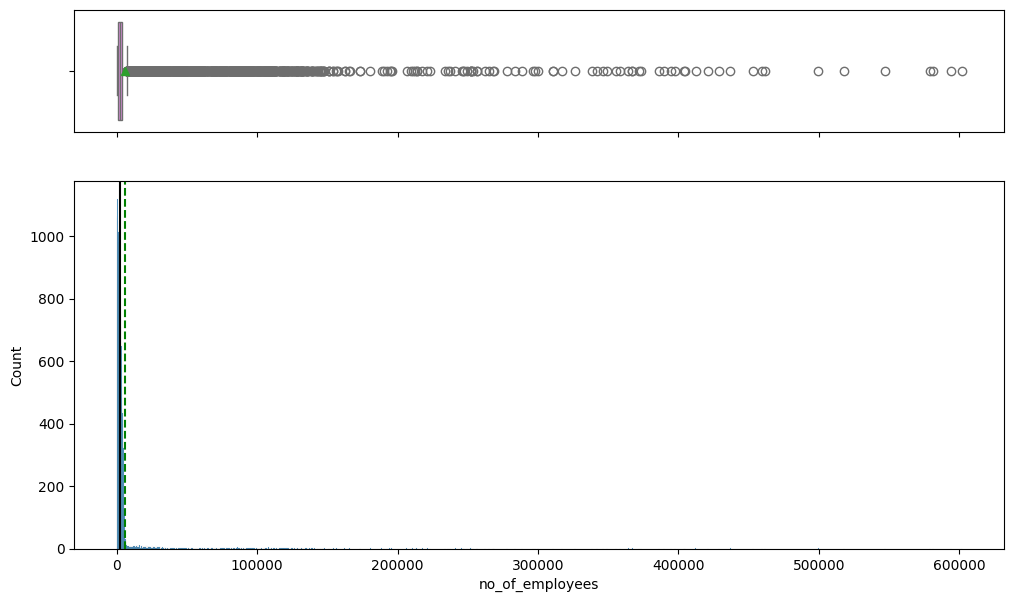

In [16]:
# Observations on Applicant's company's number of employees
histogram_boxplot(data, "no_of_employees")

##Observations
1. For number of employees, the distribution has a median of 2000 and mean of 5000, but the distribution is heavily right skewed showing that the outlier companies have much bigger employee numbers.  
2. This shows that far higher set of smaller companies have applicants, while bigger companies have perhaps a fewer of overall number of applicants.

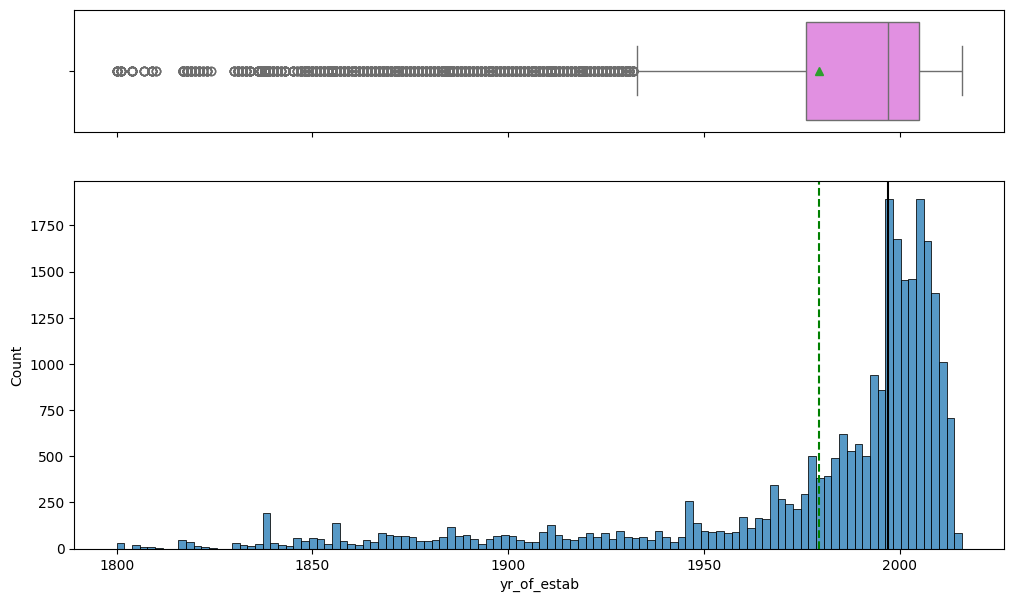

In [17]:
# Observations on Applicant's company's year of establishment
histogram_boxplot(data, "yr_of_estab")

##Observations
1. For year of establishment, the curve is left skewed.  This shows that while a lot of companies were established after 1979 (the distribution mean), a smaller outlier set of companies were established much earlier.
2.  This left skew causes the mean of 1979 to be much lower than the median of 1997.

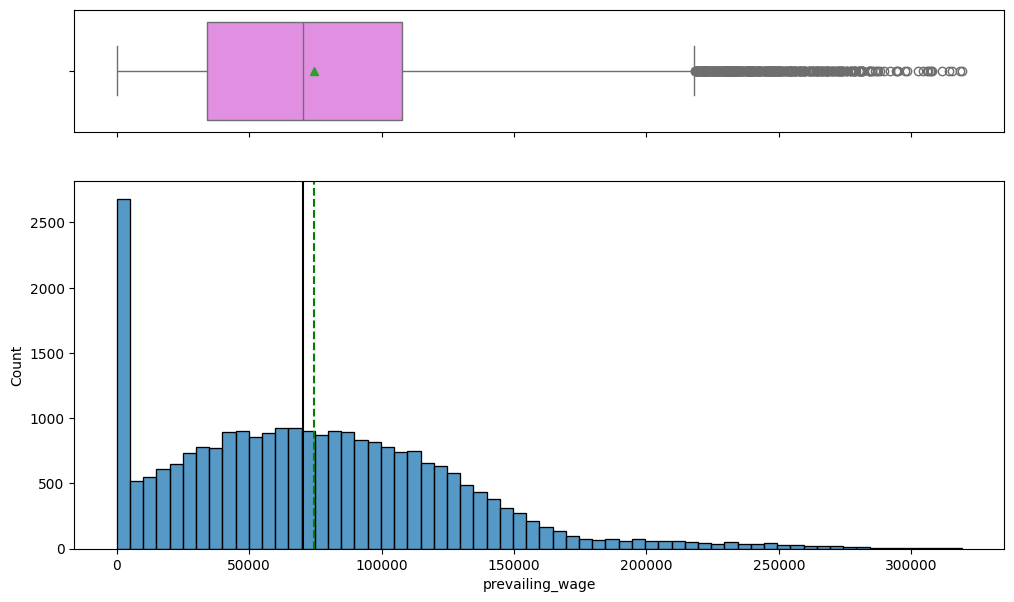

In [18]:
# Observations on Applicant's position's prevailing wage
histogram_boxplot(data, "prevailing_wage")

##Observations
1. While a lot of positions have low prevailing wage, there are several outliers as well that cause the overall mean and median to be close to each other.  The distribution is closer to normal than all other numberical data distributions for this dataset.

In [19]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

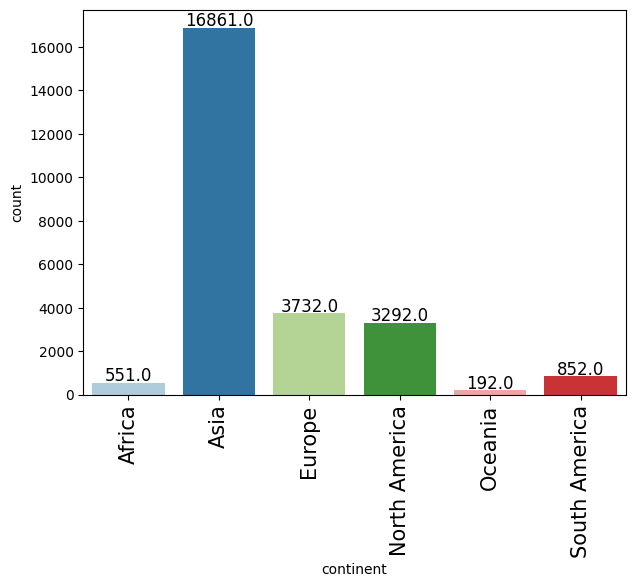

In [20]:
# observations on Applicant Continent
labeled_barplot(data, "continent")

##Observations
1. About 70% of the applicants are from Asia, followed by about 12% each from Europe and North America.  Applications from South America, Africa, and Oceania

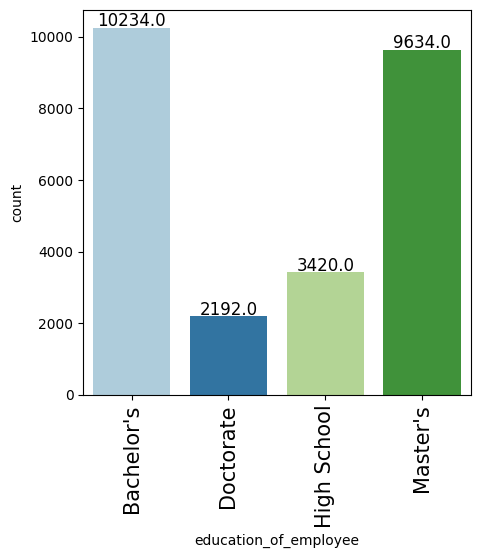

In [21]:
# observations on Applicant Education
labeled_barplot(data, "education_of_employee")

##Observations
1. About 40% of the applicants are Bachelor's degree holders, while 35% are Master's.  Only about 15% and 10% of the applicants are high school and Doctorate degree holders.

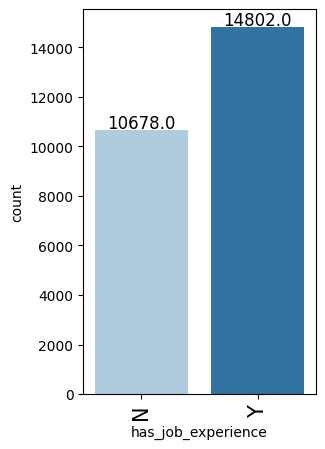

In [22]:
# observations on Applicant Experience
labeled_barplot(data, "has_job_experience")

##Observations
1. About 60% of the applicants have job experience while 40% do not.

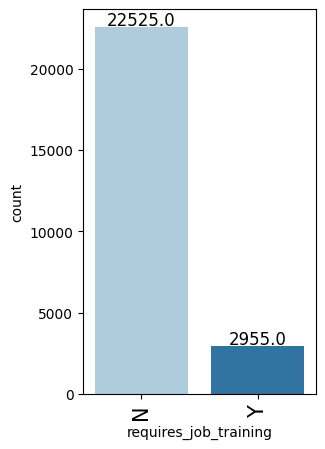

In [23]:
# observations on Applicant training requirement
labeled_barplot(data, "requires_job_training")

##Observations
1. About 87% of the applicants do not require job training.

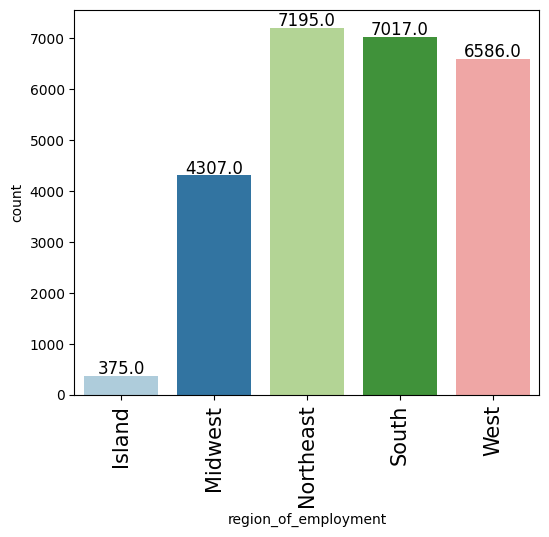

In [24]:
# observations on Job's employment region
labeled_barplot(data, "region_of_employment")

##Observations
1. Region of employment is roughly equally split between North-East, South, and West; while MidWest and Island combine to form roughly similar requirement.

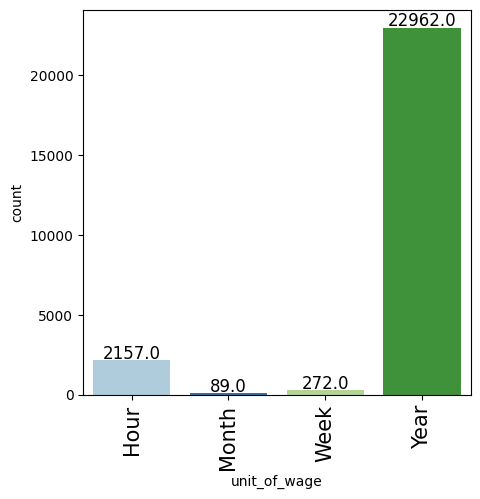

In [25]:
# observations on Job's employment region
labeled_barplot(data, "unit_of_wage")

##Observations
1. Over 85% of the wages have been expressed in yearly terms

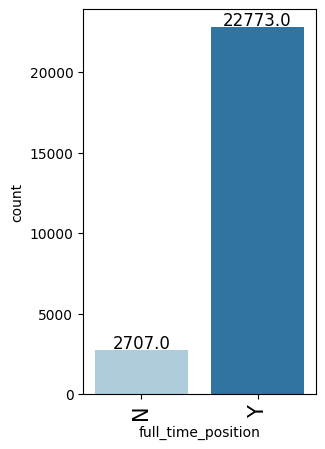

In [26]:
# observations on Job's employment region
labeled_barplot(data, "full_time_position")

##Observations
1. Over 85% of the positions are full-time, while the rest are part-time


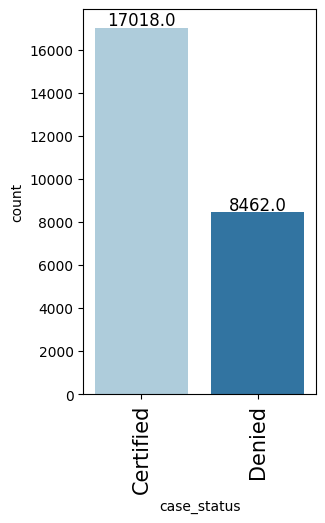

In [27]:
# observations on Job's employment region
labeled_barplot(data, "case_status")

##Observations
1. About 33% of the applicants were denied visa, showing imbalance in the eventual decision flag.


##**Bivariate Analysis**

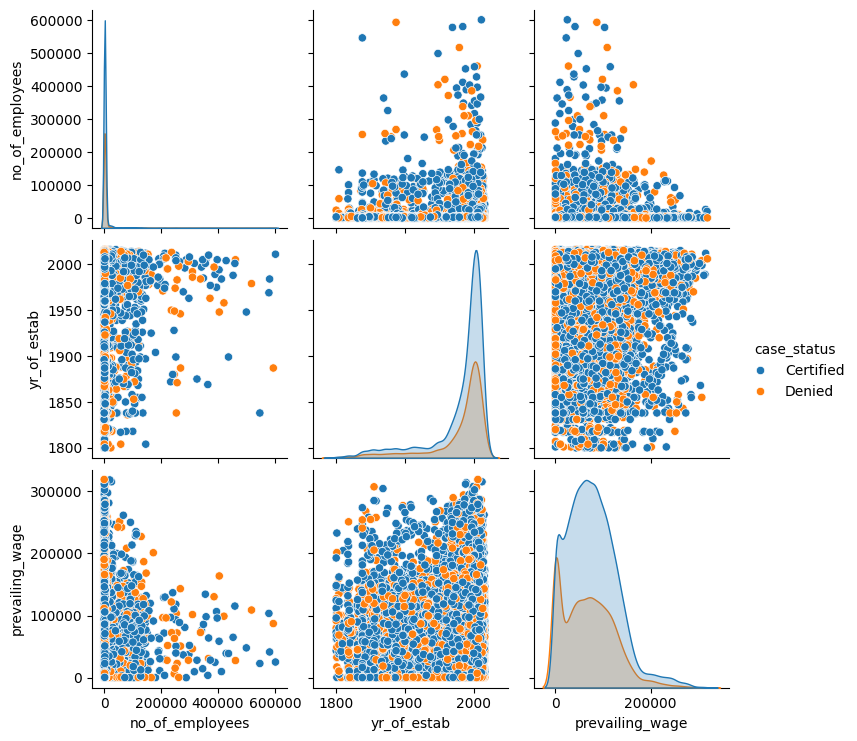

In [28]:
sns.pairplot(data, hue="case_status")

##Observations
1. A clear patterns is hard to make out, but in general, visa denials seem to be higher for roles with lower prevailing wages.  
2.  Year of establishment and number of employees seem to have no clear impact on the visa acceptance.


In [29]:
### Function to plot distributions


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

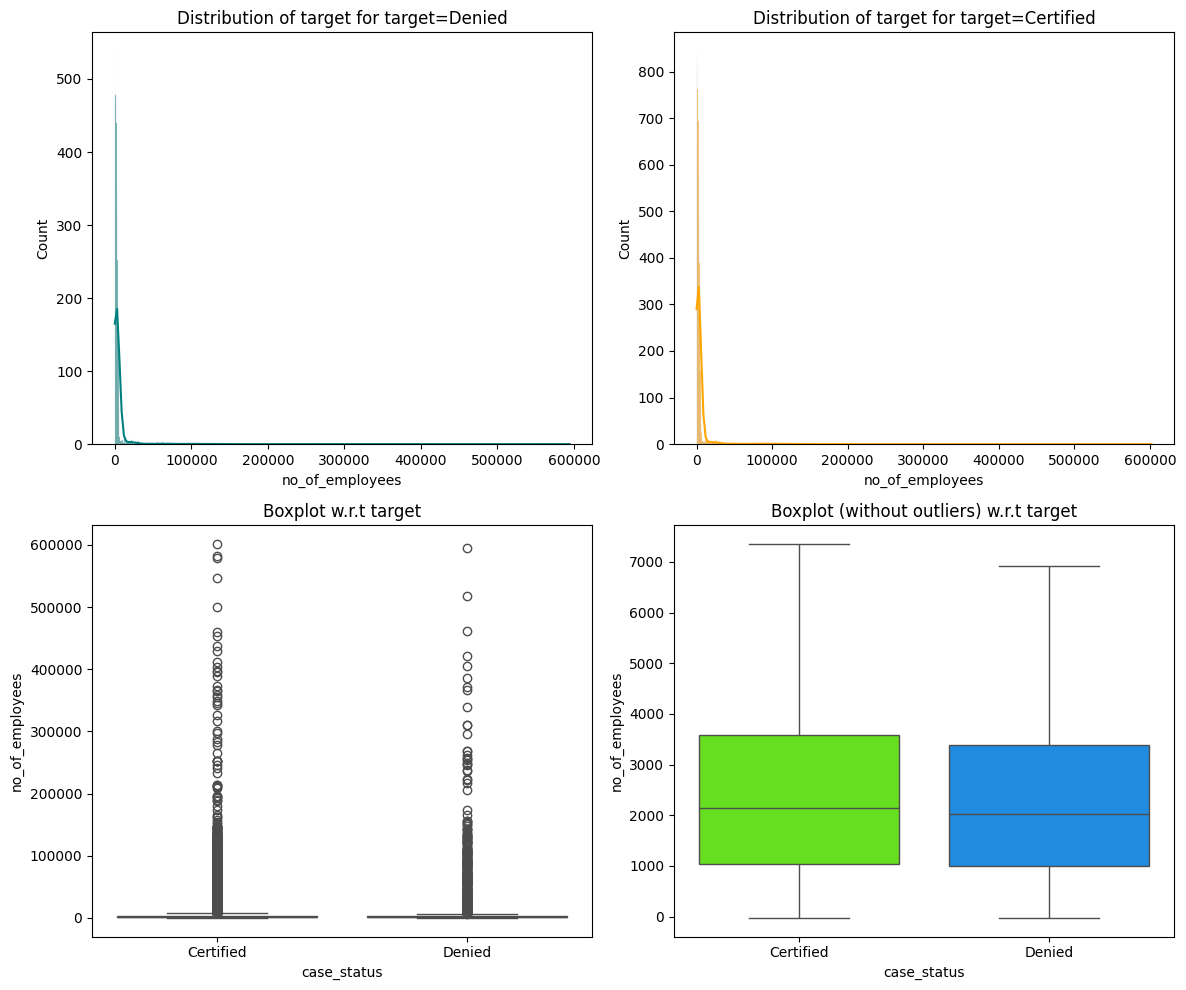

In [30]:
#plot impact of applicant company's number of employees
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

In [31]:
#document impact of number of employees on visa status
data.groupby("case_status")["no_of_employees"].describe()


,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.000,5807.018,23119.575,-26.000,1035.250,2147.000,3575.000,602069.000
Denied,8462.000,5385.538,22382.756,-26.000,991.000,2032.500,3386.750,594472.000


##Observations
1. Number of employees has a small impact on visa acceptance or denial.  Marginally, the companies with fewer employees meaning smaller companies have a higher chance of visa denial.

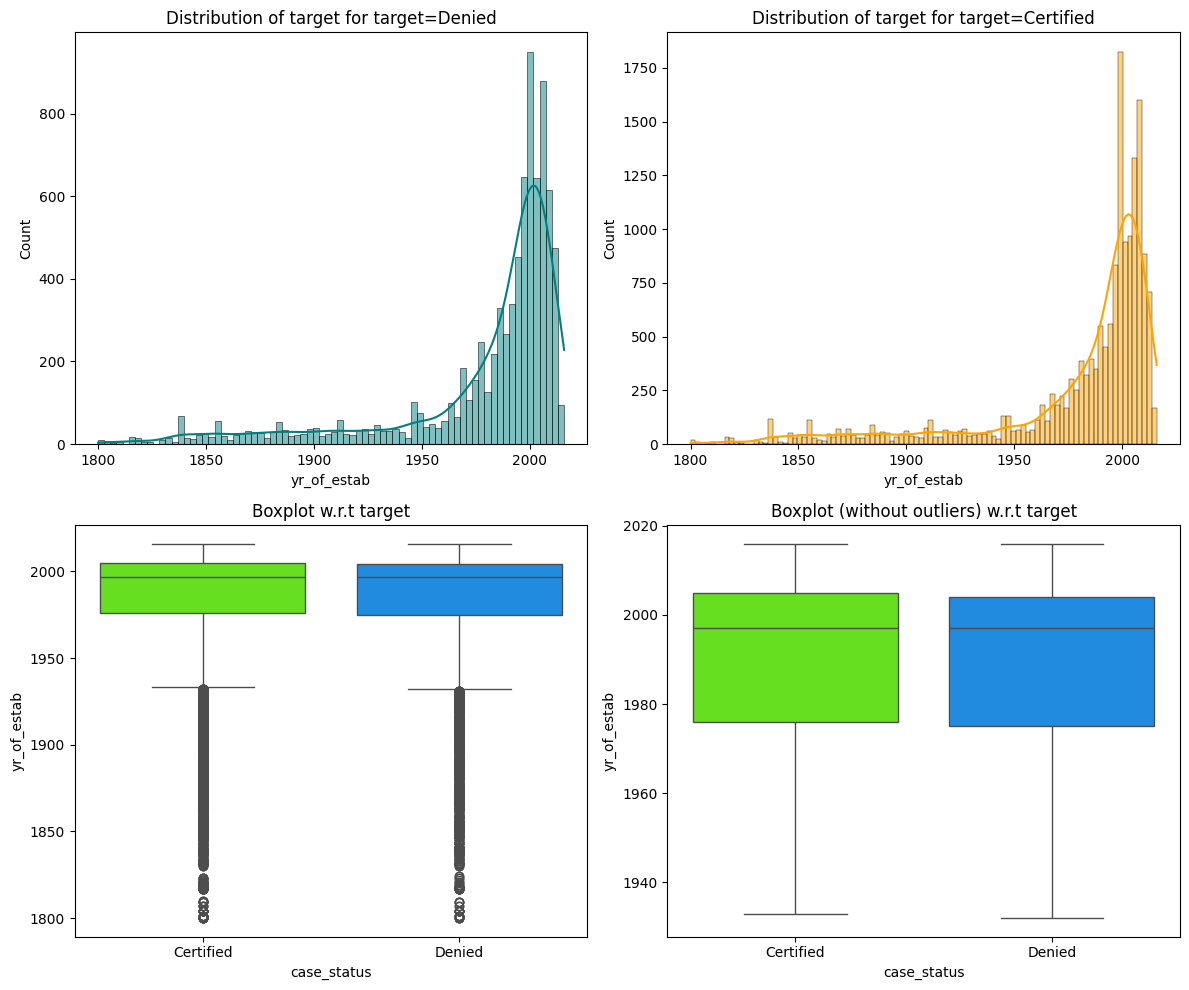

In [32]:
#plot impact of applicant company's year of establishment
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

In [33]:
#document impact of year of establishment on visa status
data.groupby("case_status")["yr_of_estab"].describe()


,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.000,1979.667,42.279,1800.000,1976.000,1997.000,2005.000,2016.000
Denied,8462.000,1978.893,42.542,1800.000,1975.000,1997.000,2004.000,2016.000


##Observations
1.  Year of establishment seems to have no clear impact on the visa acceptance.  Both younger and older companies seem to have simlar acceptance or denial rates.


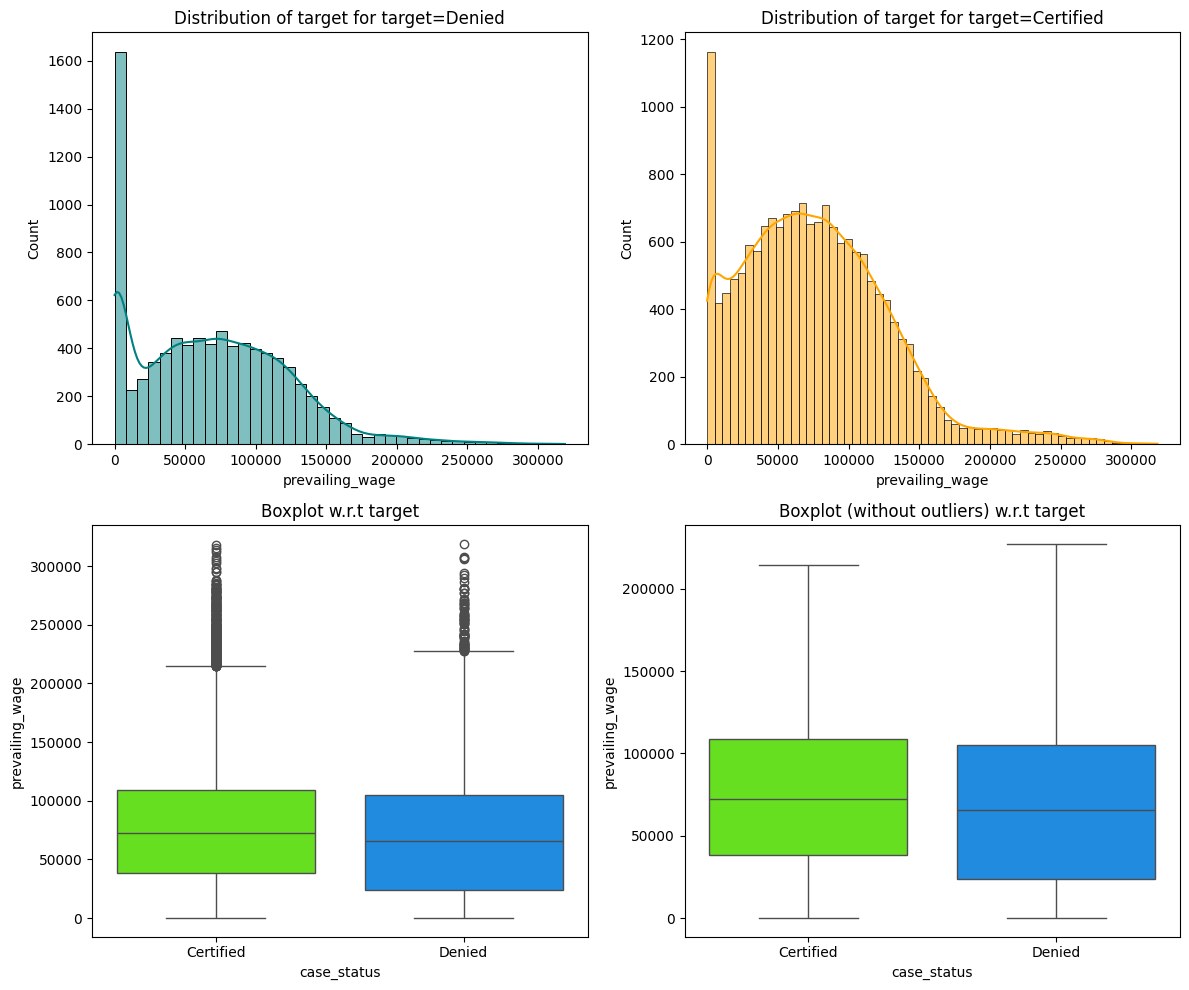

In [34]:
#plot impact of role's prevailing wage
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

In [35]:
#document impact of year of prevailing wage on visa status
data.groupby("case_status")["prevailing_wage"].describe()


,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.000,77293.619,52042.716,2.137,38375.330,72486.270,108879.107,318446.050
Denied,8462.000,68748.682,53890.166,2.956,23497.295,65431.460,105097.640,319210.270


##Observations
1. Although not a very strong trend, roles with lower prevailing wages have higher chance of visa denial.

In [36]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    tab2 = pd.crosstab(data[predictor], data[target], margins=True,normalize='index').sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    print(tab2)

    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------
case_status    Certified  Denied
continent                       
South America      0.579   0.421
North America      0.619   0.381
Oceania            0.635   0.365
Asia               0.653   0.347
All                0.668   0.332
Africa             0.721   0.279
Europe             0.792   0.208
------------------------------------------------------------------------------------------------------------------------


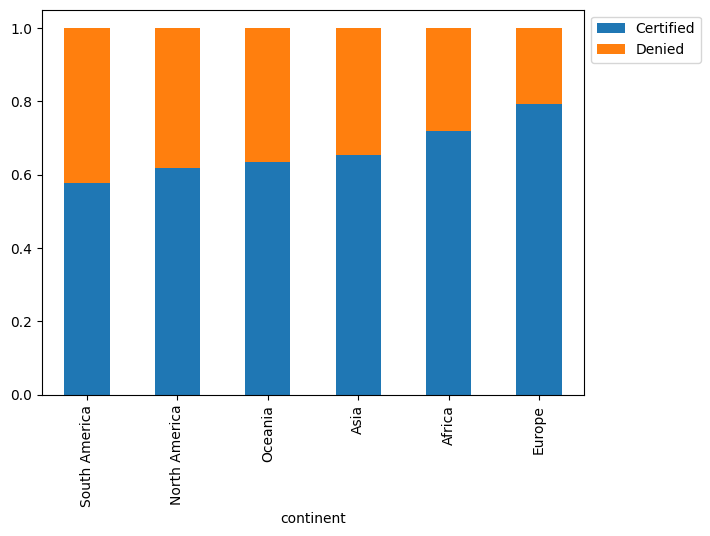

In [37]:
#Assess relationship between visa acceptance and continent
stacked_barplot(data, "continent", "case_status")

##Observations
1. Continent of applicant has a strong correlation to visa acceptance.  
2. South America followed by North America have highest visa denials of about 40% of applications.
3. Europe has the fewest visa denials at about 20% of applications.

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------
case_status            Certified  Denied
education_of_employee                   
High School                0.340   0.660
Bachelor's                 0.622   0.378
All                        0.668   0.332
Master's                   0.786   0.214
Doctorate                  0.872   0.128
------------------------------------------------------------------------------------------------------------------------


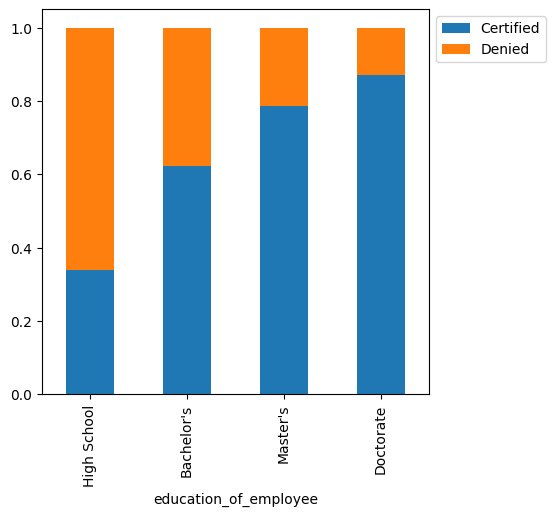

In [38]:
#Assess relationship between visa acceptance and applicant education
stacked_barplot(data, "education_of_employee", "case_status")

##Observations
1. Applicant Education has a very strong impact on visa acceptance.
2. Approximately, High school graduates have a 70% denial rate, bachelor's have 40%, master's have 20%, and doctorates have only 10% denial rate respectively.

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------
case_status         Certified  Denied
has_job_experience                   
N                       0.561   0.439
All                     0.668   0.332
Y                       0.745   0.255
------------------------------------------------------------------------------------------------------------------------


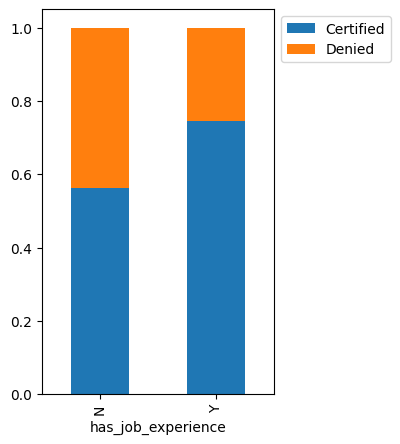

In [39]:
#Assess relationship between visa acceptance and applicant job experience
stacked_barplot(data, "has_job_experience", "case_status")

##Observations
1. Job experience has also a strong relationship to visa acceptance.
2. Approximately, applicants with no job experience have 40%+ chance of denial, while applicants with experience  have a little over 25% chance of visa denial.

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------
case_status            Certified  Denied
requires_job_training                   
N                          0.666   0.334
All                        0.668   0.332
Y                          0.679   0.321
------------------------------------------------------------------------------------------------------------------------


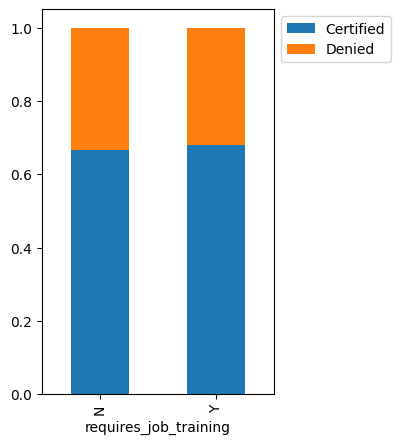

In [40]:
#Assess relationship between visa acceptance and applicant requiring training
stacked_barplot(data, "requires_job_training", "case_status")

##Observations
1. Requiring or not requiring training does not have a strong impact on visa acceptance.
2. Approximately, applicants denial rate is simlar to about 30% whether or not they need training for the job.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------
case_status   Certified  Denied
unit_of_wage                   
Hour              0.346   0.654
Month             0.618   0.382
Week              0.621   0.379
All               0.668   0.332
Year              0.699   0.301
------------------------------------------------------------------------------------------------------------------------


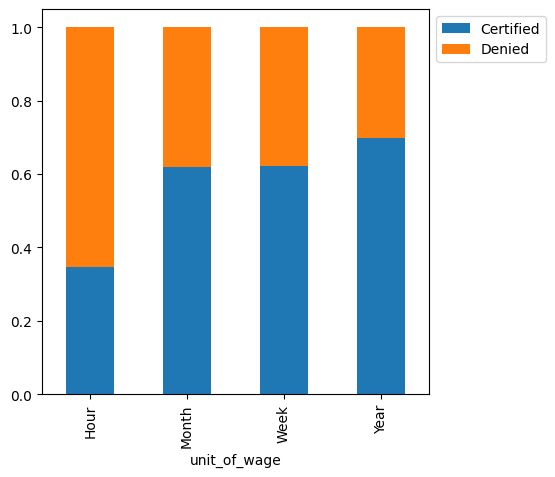

In [41]:
#Assess relationship between visa acceptance and role's unit of wage
stacked_barplot(data, "unit_of_wage", "case_status")

##Observations
1. Unit of wage has a strong impact on visa acceptance.
2. Approximately, 65% of hourly wage applications get denied while only about 30% of annual wage applications get declined.

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------
case_status         Certified  Denied
full_time_position                   
Y                       0.666   0.334
All                     0.668   0.332
N                       0.685   0.315
------------------------------------------------------------------------------------------------------------------------


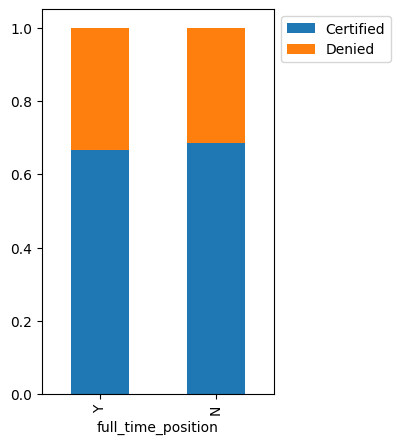

In [42]:
#Assess relationship between visa acceptance and job being full time or part time
stacked_barplot(data, "full_time_position", "case_status")

##Observations
1. Full time versus part time does not have a strong impact on visa acceptance rate.
2. Approximately, 33% of applications are declined for both full time and part time roles.

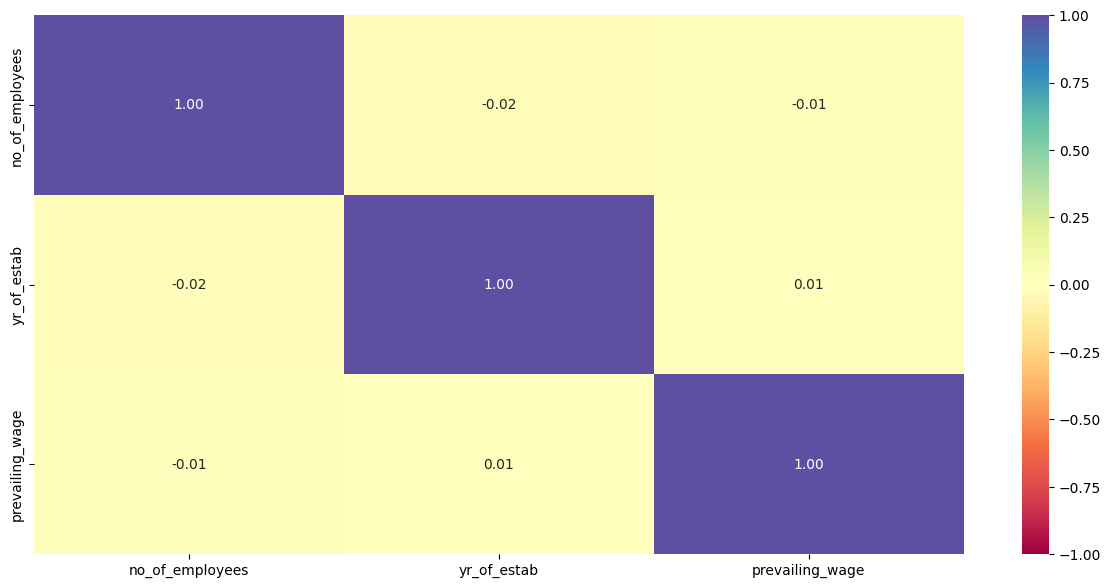

In [43]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

##Observations
1. No strong positive or negative correlations amongst any of the numerical variables.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

##**Feature Engineering**
Organization's Number of employees and year of establishment can be converted to categorical variables.  However, we shall do this after train, validation, test, split to avoid data leakage.

In [62]:
#Form predictor and target sets
X = data.drop(["case_status","case_id"], axis=1) #Remove target column and id columns
y = data["case_status"]

In [63]:
#Explicitly convert case status to 0 or 1 to make it categorical
y = y.replace({'Certified': 0, 'Denied': 1})


In [64]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
#Check number of rows and columns in predictor set
print(X_train.shape, X_val.shape, X_test.shape)
#Confirm stratification in each target set
print(y_train.value_counts(normalize='True'),y_val.value_counts(normalize='True'),y_test.value_counts(normalize='True'))


(15288, 10) (5096, 10) (5096, 10)
case_status
0   0.668
1   0.332
Name: proportion, dtype: float64 case_status
0   0.668
1   0.332
Name: proportion, dtype: float64 case_status
0   0.668
1   0.332
Name: proportion, dtype: float64


##Observations
1. The dataset is now split 60%, 20%, 20% in training, validation, and test set
2. Since there are no missing values, the dataset needs no missing value treatment.
3.  While the dataset has some outliers, none of those are invalid observations, so there is no need for outlier treatment.
4. The only pre-treatment needed was to explicitly convert y from object to categorical datatype so that the modeling performs smoothly.


In [65]:
# Discretize variable into equal-sized buckets based on quantiles
#Get quartile conversions of the other three columns
#Use bins to categorize the columns into specific buckets
# 'labels' provides names for the new categories
conv_col=['no_of_employees','yr_of_estab','prevailing_wage']
for col in conv_col:
  if col == 'no_of_employees':
    bins= [0,1000,2100,3500,1000000]
    labels = ['Less than 1000 employees', '1000-2100 employees', '2100-3500','more than 3500']
  else :
    if col == 'yr_of_estab':
      bins= [1700,1976,1997,2005,2026]
      labels = ['before 1976', 'between 1977-1997', 'between 1998-2005','after 2005']
    else :
      if col == 'prevailing_wage':
        bins= [0,34000,70000,108000,10000000]
        labels = ['less than 34k', '34-70k', '70-108k','more than 108k']
  X_train[col] = pd.cut(data[col], bins=bins,labels=labels,right=False)
  X_val[col] = pd.cut(data[col], bins=bins,labels=labels,right=False)
  X_test[col] = pd.cut(data[col], bins=bins,labels=labels,right=False)


In [66]:
# Convert all these columns to categorical explicitly
for col in conv_col:
  X_train[col] = X_train[col].astype("category")
  X_val[col] = X_val[col].astype("category")
  X_test[col] = X_test[col].astype("category")
  print("for X_train",X_train[col].value_counts())
  print("for X_val",X_val[col].value_counts())
  print("for X_test",X_test[col].value_counts())

for X_train no_of_employees
2100-3500                   3903
1000-2100 employees         3857
more than 3500              3778
Less than 1000 employees    3735
Name: count, dtype: int64
for X_val no_of_employees
more than 3500              1303
1000-2100 employees         1276
2100-3500                   1260
Less than 1000 employees    1248
Name: count, dtype: int64
for X_test no_of_employees
1000-2100 employees         1327
more than 3500              1307
2100-3500                   1234
Less than 1000 employees    1219
Name: count, dtype: int64
for X_train yr_of_estab
after 2005           4028
between 1998-2005    3907
before 1976          3800
between 1977-1997    3553
Name: count, dtype: int64
for X_val yr_of_estab
after 2005           1362
between 1998-2005    1296
before 1976          1226
between 1977-1997    1212
Name: count, dtype: int64
for X_test yr_of_estab
after 2005           1361
before 1976          1300
between 1998-2005    1280
between 1977-1997    1155
Name: count,

In [67]:
# Creating dummy variables for categorical variables but shift them to int as functions like SMOTE expect ints
X_train = pd.get_dummies(data=X_train, drop_first=True).astype("int")
X_val = pd.get_dummies(data=X_val, drop_first=True).astype("int")
X_test = pd.get_dummies(data=X_test, drop_first=True).astype("int")

In [68]:
X_train.head() #Confirming that the dataset is correctly one-hot encoded

,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,no_of_employees_1000-2100 employees,no_of_employees_2100-3500,no_of_employees_more than 3500,yr_of_estab_between 1977-1997,yr_of_estab_between 1998-2005,yr_of_estab_after 2005,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,prevailing_wage_34-70k,prevailing_wage_70-108k,prevailing_wage_more than 108k,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
8776,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,1,1
8510,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1
2449,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1
5367,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,1
5294,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,1


# **Model Building**

#Model evaluation criterion
In this context, the applicants who should get the visa should not be denied visas by the model.  Thus, false positives should be low, or precision should be high.  Simlarly, the applicants who do not deserve the visa should also get flagged accurately and model should not certify visa for them.  In other words, false negatives should be minimized, or recall should be maximized.  Since both are equally important needs, we will follow a balanced approach here.  In other words,  we will go with **F_1 score to be maximized**.

##**Initial Model Building**
Model building with original data

In [69]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1},
        index=[0],
    )

    return df_perf

In [70]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")


Cross-Validation Performance of training set:

Bagging: 0.5081989244320055
Random forest: 0.5188991441272743
GBM: 0.5636839483546912
Adaboost: 0.5128587049600543
Xgboost: 0.5578073536156686
dtree: 0.47701997684211

Performance of validation set:

Bagging: 0.5185647425897036
Random forest: 0.5217391304347826
GBM: 0.5698360655737705
Adaboost: 0.5370180825656773
Xgboost: 0.553519768563163
dtree: 0.47587791270101737

Training and Validation Performance Difference:

Bagging, Difference: 0.0104
Random forest, Difference: 0.0028
GBM, Difference: 0.0062
Adaboost, Difference: 0.0242
Xgboost, Difference: -0.0043
dtree, Difference: -0.0011


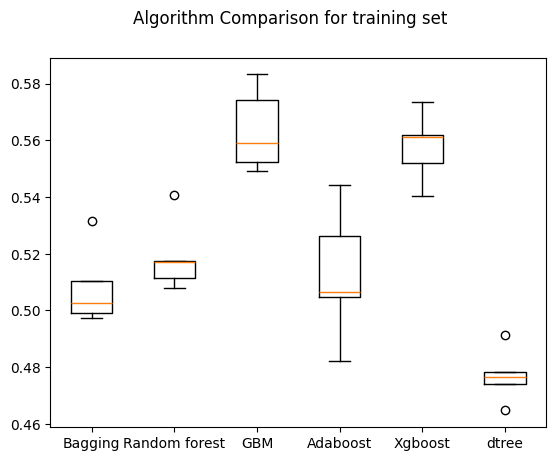

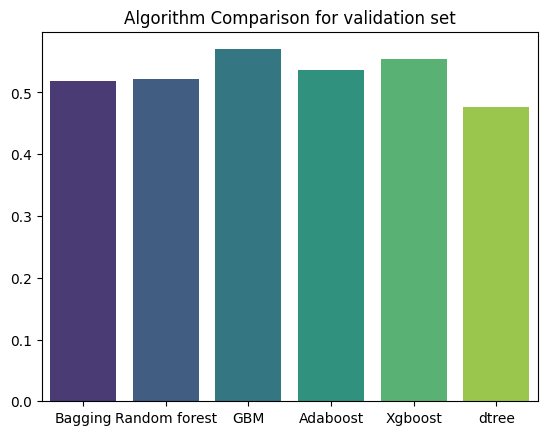

Training set performance
                Accuracy  Recall  Precision    F1
Bagging           0.855   0.728      0.817 0.770
Random forest     0.863   0.734      0.832 0.780
GBM               0.754   0.505      0.673 0.577
Adaboost          0.737   0.439      0.656 0.526
Xgboost           0.794   0.587      0.738 0.654
dtree             0.863   0.675      0.884 0.766 

Validation set Performance
                Accuracy  Recall  Precision    F1
Bagging           0.697   0.491      0.550 0.519
Random forest     0.706   0.482      0.569 0.522
GBM               0.743   0.513      0.640 0.570
Adaboost          0.734   0.465      0.636 0.537
Xgboost           0.727   0.509      0.607 0.554
dtree             0.687   0.428      0.535 0.476

Bagging  Training Performance


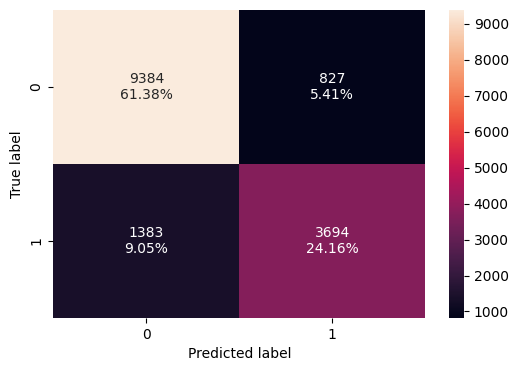


Bagging  Validation Performance


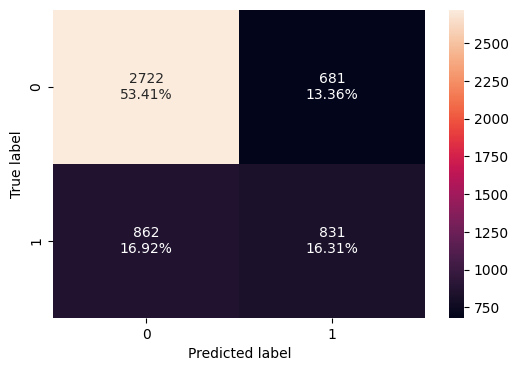


Random forest  Training Performance


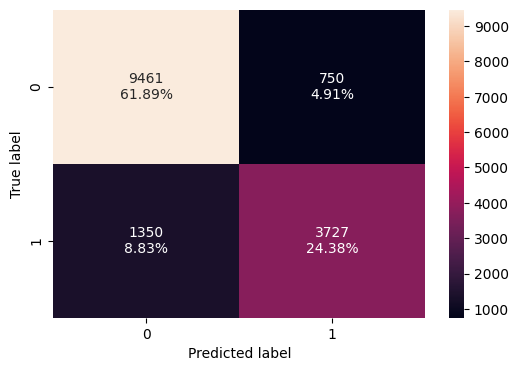


Random forest  Validation Performance


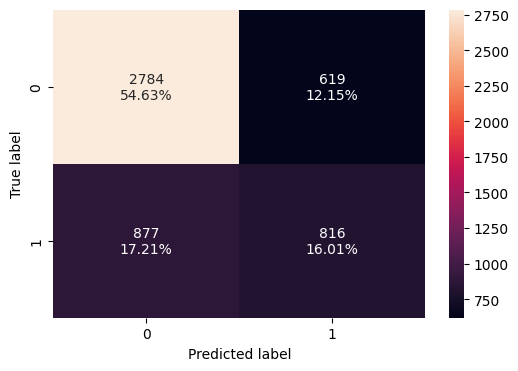


GBM  Training Performance


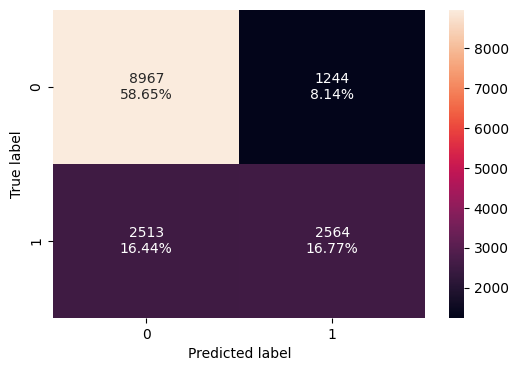


GBM  Validation Performance


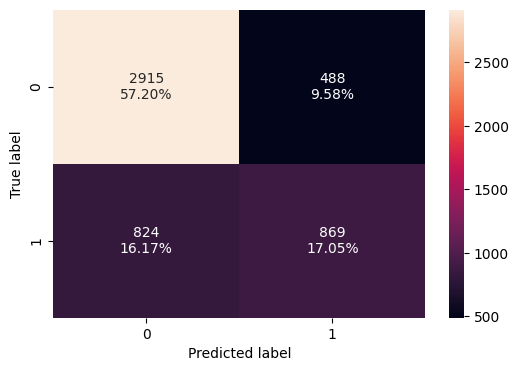


Adaboost  Training Performance


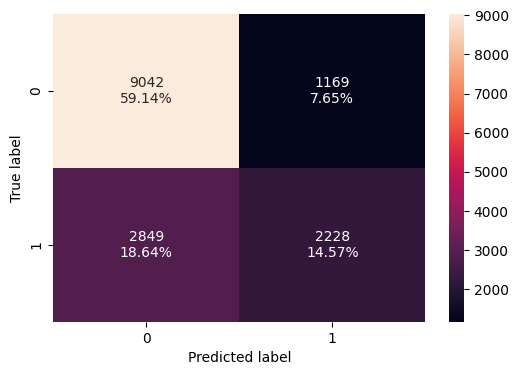


Adaboost  Validation Performance


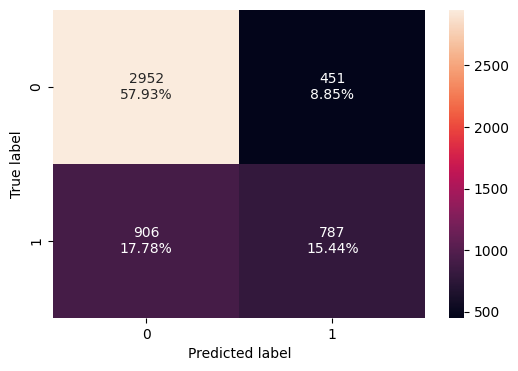


Xgboost  Training Performance


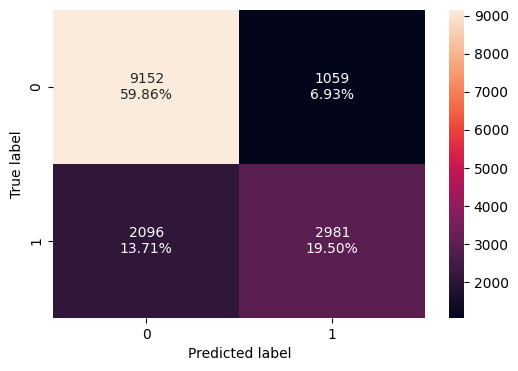


Xgboost  Validation Performance


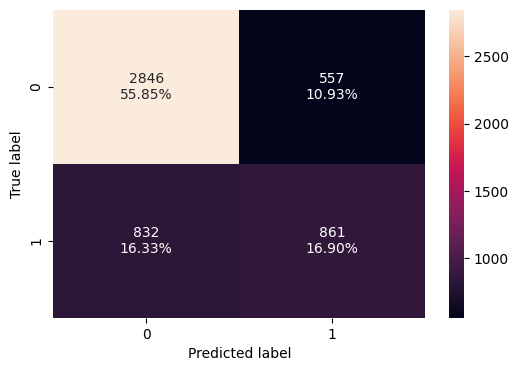


dtree  Training Performance


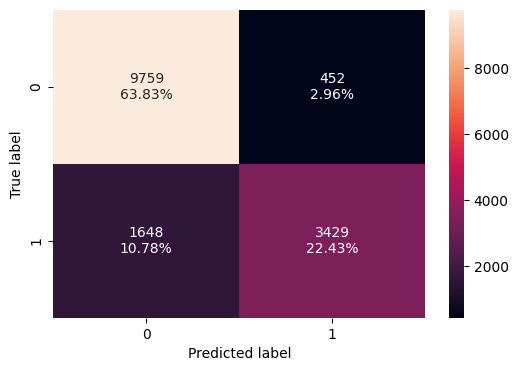


dtree  Validation Performance


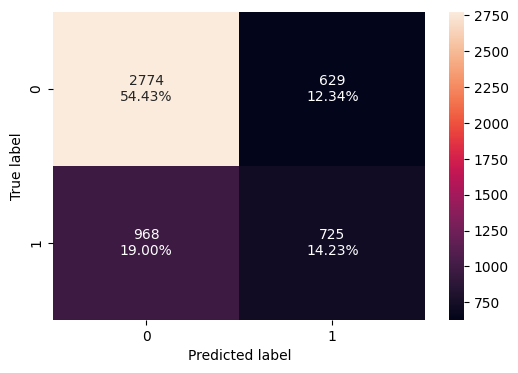

In [100]:
#Set model performance computation for Base Data

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))


# Setting number of splits equal to 5
kfold = StratifiedKFold(
n_splits=5, shuffle=True, random_state=1
)

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

print("\n" "Cross-Validation Performance of training set:" "\n")
# loop through all models to get the mean cross validated score
for name, model in models:
  scoring="f1"
  cv_result = cross_val_score(
  estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
  )
  results.append(cv_result)
  names.append(name)
  print("{}: {}".format(name, cv_result.mean()))
print("\n" "Performance of validation set:" "\n")
for name, model in models:
  model.fit(X_train, y_train)
  scores = f1_score(y_val, model.predict(X_val))
  score.append(scores)
  print("{}: {}".format(name, scores))


  # Plotting boxplots for CV scores of all models defined above for training set
print("\nTraining and Validation Performance Difference:\n")
i=0
for name,model in models:
  difference = score[i] - results[i].mean()
  print("{}, Difference: {:.4f}".format(name, difference))
  i=i+1

fig = plt.figure()
fig.suptitle("Algorithm Comparison for training set")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()
# Plotting barcharts for CV scores of all models defined above for validation set
fig = plt.figure()
sns.barplot(x=names,y=score,palette='viridis')
plt.title("Algorithm Comparison for validation set")
plt.show()


#Collate all accuracy scores for all models in one table for quick and easy comparison
dir_train={}
dir_val={}
i=[]
for name, model in models:
  #print("\n" + name," Training Performance")
  dir_train[name] = pd.DataFrame(model_performance_classification_sklearn(model, X_train, y_train))
  #print("\n" + name," Validation Performance")
  dir_val[name] = (model_performance_classification_sklearn(model, X_val, y_val))
  i.append(name)
df_train=pd.concat([dir_train[name] for name in dir_train.keys()],ignore_index=True)
df_val=pd.concat([dir_val[name] for name in dir_val.keys()],ignore_index=True)
df_train.index=i
df_val.index=i
print("Training set performance\n",df_train,"\n\nValidation set Performance\n", df_val)

#Plot confusion matrix for all models for both training and validation sets
for name, model in models:
  print("\n" + name," Training Performance")
  (confusion_matrix_sklearn(model, X_train, y_train))
  plt.show()
  print("\n" + name," Validation Performance")
  (confusion_matrix_sklearn(model, X_val, y_val))
  plt.show()

##Observations
1. GBM, Adaboost, and XGBoost are performing slightly better than other models.   Random Forest and Bagging are quite close in terms of f1 scores as well.  Decision Tree score is lagging in f1 score compared to the former models.
2. Bagging, Random Forest, and Decision Tree have much higher training scores than validation scores, showing that they are overfitting the training data.
3. So far, GBM is the best model as it has the best f1 score.

##Observations
1. Since the decision flag is imbalanced, now let us try oversampling and undersampling to see how each of the models improve in these scenarios.
2.  Since all the models are quite close to each other in their performance, let us perform oversampling and undersampling on all the models before screening out any model.

**Model Building - Oversampled Data**

In [101]:
print("Before Oversampling, counts of label 'Denied': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Certified': {} \n".format(sum(y_train == 0)))
#categorical_features = X_train.select_dtypes(include=["category"]).columns

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Denied': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Certified': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Denied': 5077
Before Oversampling, counts of label 'Certified': 10211 

After Oversampling, counts of label 'Denied': 10211
After Oversampling, counts of label 'Certified': 10211 

After Oversampling, the shape of train_X: (20422, 27)
After Oversampling, the shape of train_y: (20422,) 




Cross-Validation Performance of training set:

Bagging: 0.7412626591860392
Random forest: 0.7504209927051823
GBM: 0.7251802326788805
Adaboost: 0.6965200643051604
Xgboost: 0.7393128181309523
dtree: 0.7222649965262213

Performance of validation set:

Bagging: 0.5440900562851783
Random forest: 0.5564897530215449
GBM: 0.6106172212344425
Adaboost: 0.5948502364687336
Xgboost: 0.5856763925729443
dtree: 0.5372807017543859

Training and Validation Performance Difference:

Bagging, Difference: -0.1972
Random forest, Difference: -0.1939
GBM, Difference: -0.1146
Adaboost, Difference: -0.1017
Xgboost, Difference: -0.1536
dtree, Difference: -0.1850


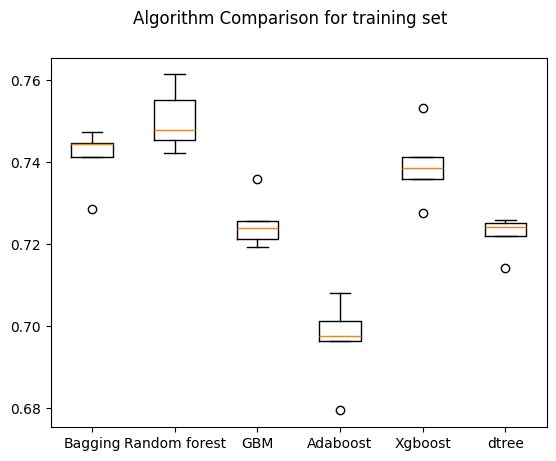

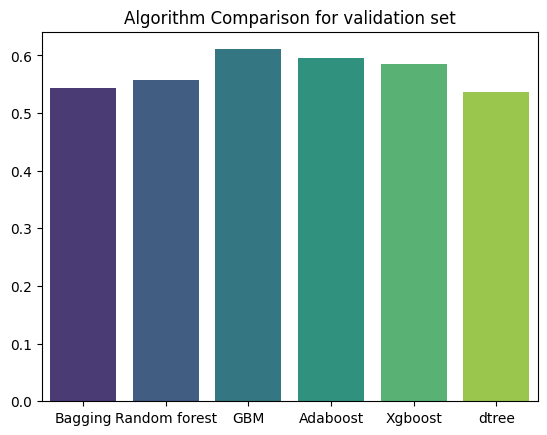

Training set performance
                Accuracy  Recall  Precision    F1
Bagging           0.855   0.885      0.836 0.859
Random forest     0.861   0.896      0.837 0.866
GBM               0.725   0.743      0.717 0.730
Adaboost          0.702   0.677      0.712 0.694
Xgboost           0.784   0.797      0.776 0.787
dtree             0.861   0.868      0.856 0.862 

Validation set Performance
                Accuracy  Recall  Precision    F1
Bagging           0.666   0.600      0.498 0.544
Random forest     0.669   0.626      0.501 0.556
GBM               0.699   0.710      0.536 0.611
Adaboost          0.697   0.669      0.536 0.595
Xgboost           0.693   0.652      0.532 0.586
dtree             0.669   0.579      0.501 0.537

Bagging  Training Performance


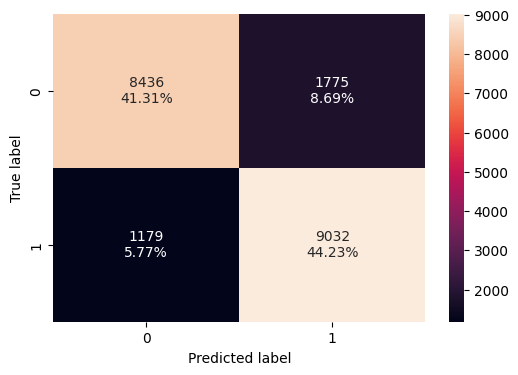


Bagging  Validation Performance


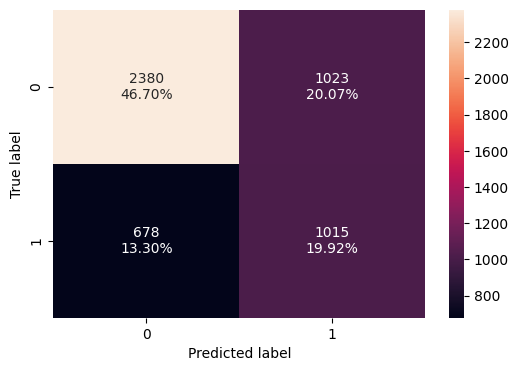


Random forest  Training Performance


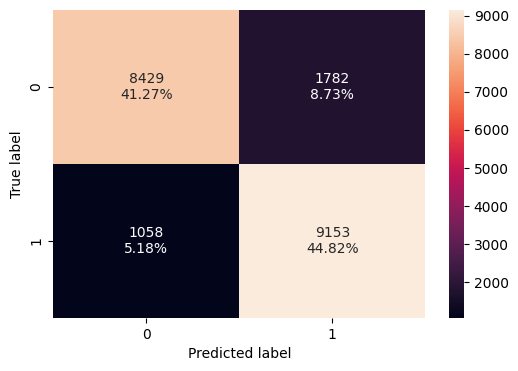


Random forest  Validation Performance


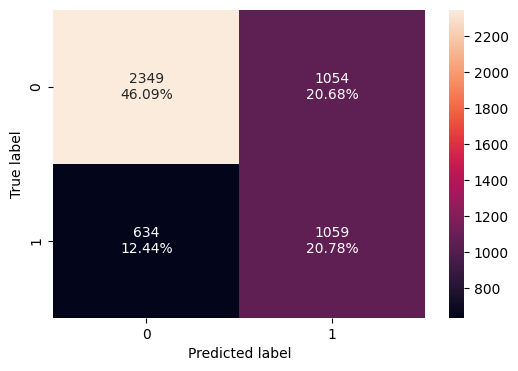


GBM  Training Performance


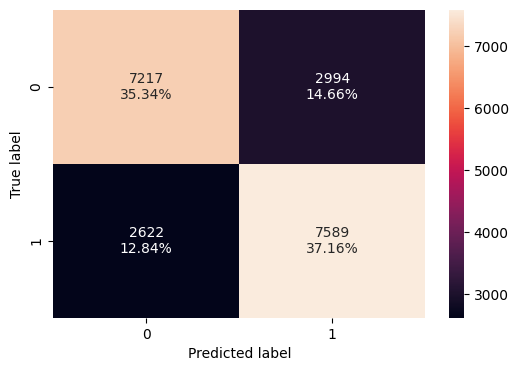


GBM  Validation Performance


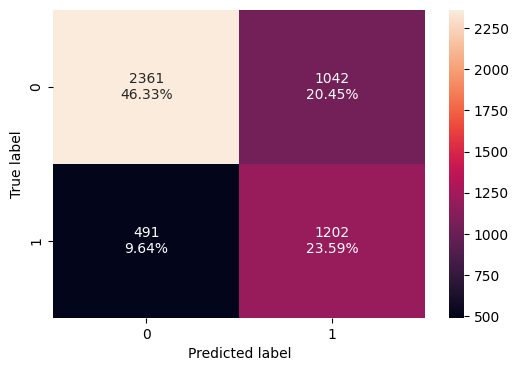


Adaboost  Training Performance


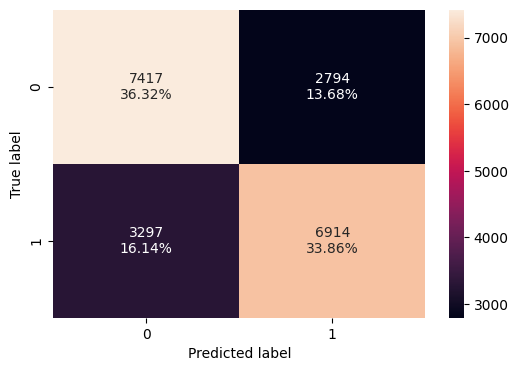


Adaboost  Validation Performance


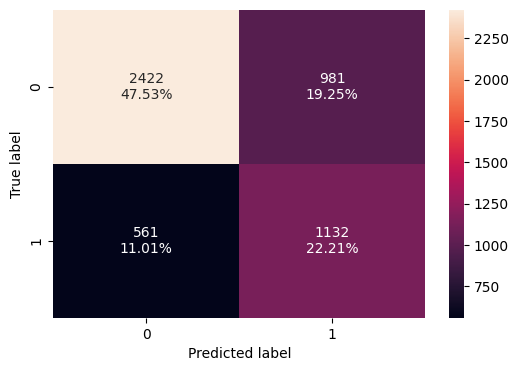


Xgboost  Training Performance


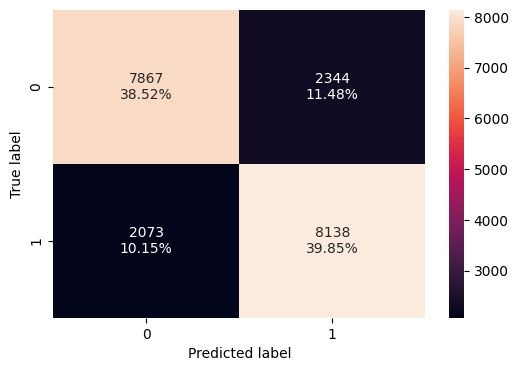


Xgboost  Validation Performance


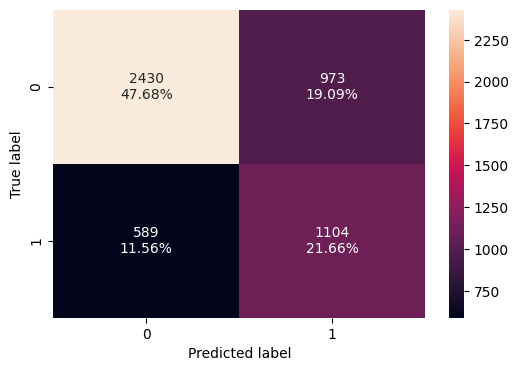


dtree  Training Performance


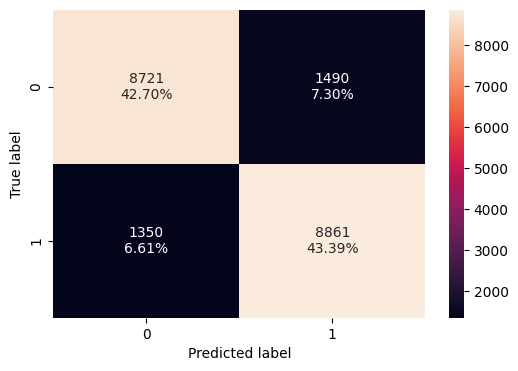


dtree  Validation Performance


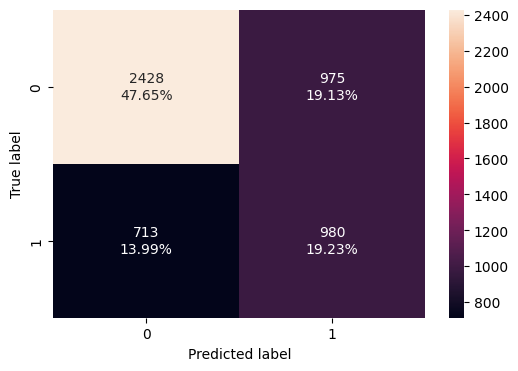

In [104]:
#Set model performance computation for Oversampled Data
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))


# Setting number of splits equal to 5
kfold = StratifiedKFold(
n_splits=5, shuffle=True, random_state=1
)

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

print("\n" "Cross-Validation Performance of training set:" "\n")
# loop through all models to get the mean cross validated score
for name, model in models:
  scoring="f1"
  cv_result = cross_val_score(
  estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
  )
  results.append(cv_result)
  names.append(name)
  print("{}: {}".format(name, cv_result.mean()))
print("\n" "Performance of validation set:" "\n")
for name, model in models:
  model.fit(X_train_over, y_train_over)
  scores = f1_score(y_val, model.predict(X_val))
  score.append(scores)
  print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models defined above for training set
print("\nTraining and Validation Performance Difference:\n")
i=0
for name,model in models:
  difference = score[i] - results[i].mean()
  print("{}, Difference: {:.4f}".format(name, difference))
  i=i+1
fig = plt.figure()
fig.suptitle("Algorithm Comparison for training set")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()
# Plotting barcharts for CV scores of all models defined above for validation set
fig = plt.figure()
sns.barplot(x=names,y=score,palette='viridis')
plt.title("Algorithm Comparison for validation set")
plt.show()

#Collate all accuracy scores for all models in one table for quick and easy comparison
dir_train={}
dir_val={}
i=[]
for name, model in models:
  #print("\n" + name," Training Performance")
  dir_train[name] = pd.DataFrame(model_performance_classification_sklearn(model, X_train_over, y_train_over))
  #print("\n" + name," Validation Performance")
  dir_val[name] = (model_performance_classification_sklearn(model, X_val, y_val))
  i.append(name)
df_train=pd.concat([dir_train[name] for name in dir_train.keys()],ignore_index=True)
df_val=pd.concat([dir_val[name] for name in dir_val.keys()],ignore_index=True)
df_train.index=i
df_val.index=i
print("Training set performance\n",df_train,"\n\nValidation set Performance\n", df_val)

#Plot confusion matrix for all models for both training and validation sets
for name, model in models:
  print("\n" + name," Training Performance")
  (confusion_matrix_sklearn(model, X_train_over, y_train_over))
  plt.show()
  print("\n" + name," Validation Performance")
  (confusion_matrix_sklearn(model, X_val, y_val))
  plt.show()

##Observations
1. Oversampling has improved training and validation scores across the board for all models compared to standard case.
2. The models in general have much higher training scores than validation scores.  This shows that the models are trying to overfit training data, and are generalizing less well.  However, the validation scores are still better than those in standard data, showing that the models are capturing some more of the signal than just noise.
4. GBM, Adaboost, and XGBoost continue to be the models with the best f1 scores.
5. Bagging, Random Forest, and Decision Tree have much higher training scores than validation scores in general, showing that they continue to overfit the training data.
6.  GBM continues to be the best model overall with best recall, precision, as well as f1 scores.

**Model Building - Undersampled Data**

In [105]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [106]:
print("Before Under Sampling, counts of label 'Denied': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Certified': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Denied': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Certified': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Denied': 5077
Before Under Sampling, counts of label 'Certified': 10211 

After Under Sampling, counts of label 'Denied': 5077
After Under Sampling, counts of label 'Certified': 5077 

After Under Sampling, the shape of train_X: (10154, 27)
After Under Sampling, the shape of train_y: (10154,) 




Cross-Validation Performance of training set:

Bagging: 0.6373255258807337
Random forest: 0.659296314524809
GBM: 0.7032218830899494
Adaboost: 0.687401306684476
Xgboost: 0.690677547258644
dtree: 0.6113378484426153

Performance of validation set:

Bagging: 0.5513240857503152
Random forest: 0.560663149962321
GBM: 0.6133942161339422
Adaboost: 0.6055736881747427
Xgboost: 0.5914005531807895
dtree: 0.5273209549071618

Training and Validation Performance Difference:

Bagging, Difference: -0.0860
Random forest, Difference: -0.0986
GBM, Difference: -0.0898
Adaboost, Difference: -0.0818
Xgboost, Difference: -0.0993
dtree, Difference: -0.0840


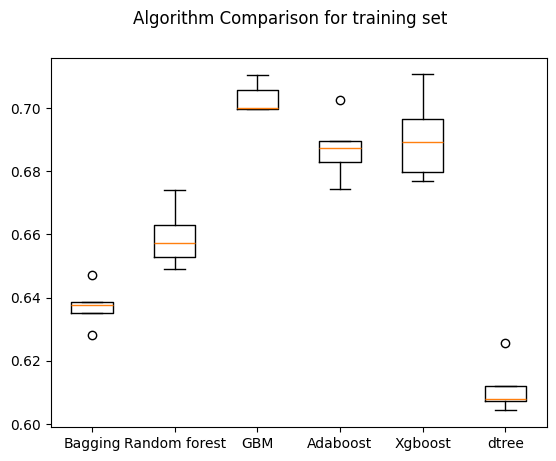

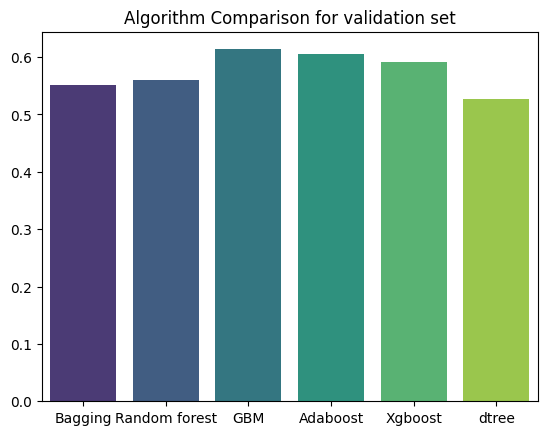

Training set performance
                Accuracy  Recall  Precision    F1
Bagging           0.857   0.857      0.857 0.857
Random forest     0.866   0.873      0.861 0.867
GBM               0.712   0.707      0.715 0.711
Adaboost          0.693   0.692      0.694 0.693
Xgboost           0.786   0.776      0.791 0.783
dtree             0.866   0.812      0.910 0.858 

Validation set Performance
                Accuracy  Recall  Precision    F1
Bagging           0.651   0.646      0.481 0.551
Random forest     0.657   0.659      0.488 0.561
GBM               0.701   0.714      0.538 0.613
Adaboost          0.692   0.712      0.527 0.606
Xgboost           0.681   0.695      0.515 0.591
dtree             0.650   0.587      0.479 0.527

Bagging  Training Performance


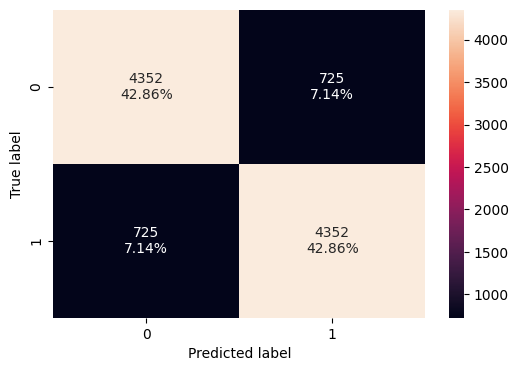


Bagging  Validation Performance


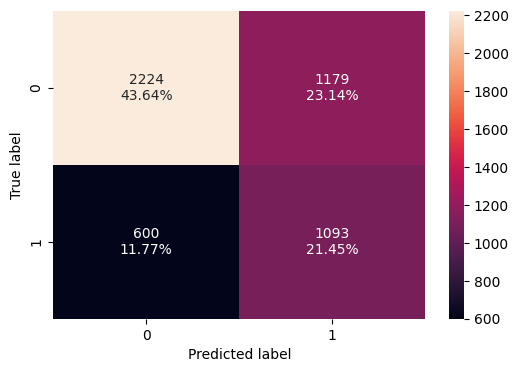


Random forest  Training Performance


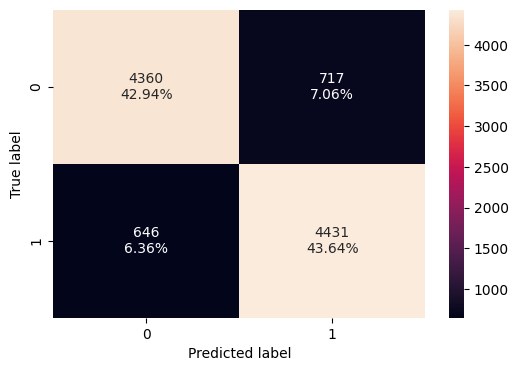


Random forest  Validation Performance


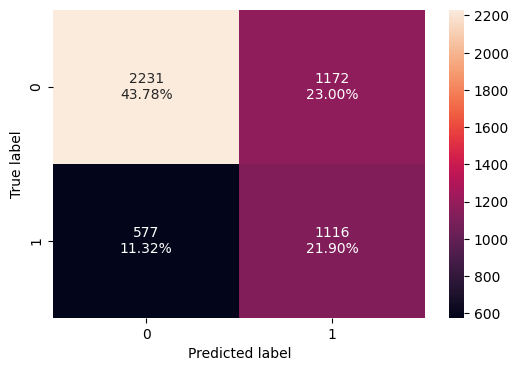


GBM  Training Performance


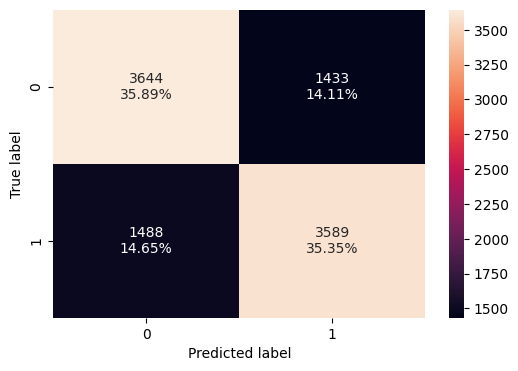


GBM  Validation Performance


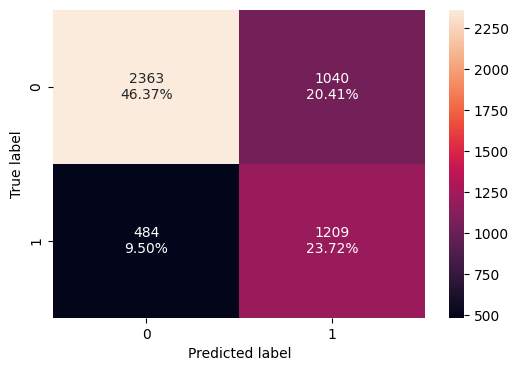


Adaboost  Training Performance


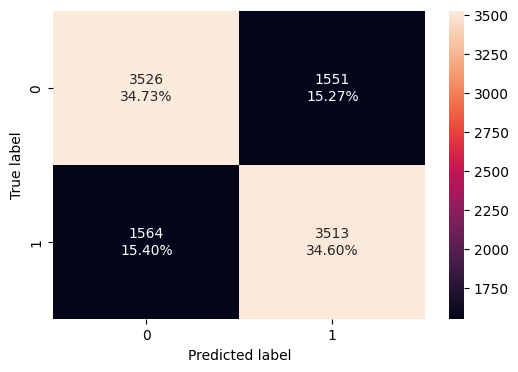


Adaboost  Validation Performance


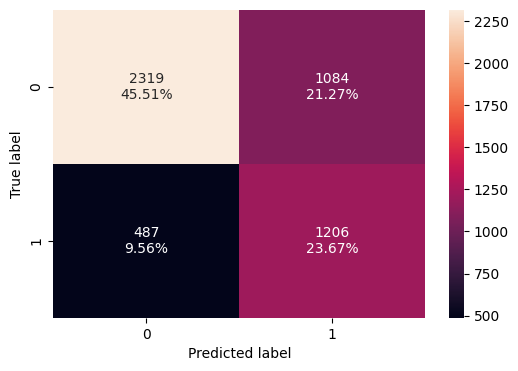


Xgboost  Training Performance


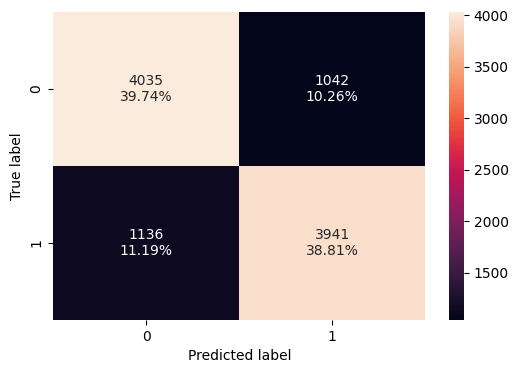


Xgboost  Validation Performance


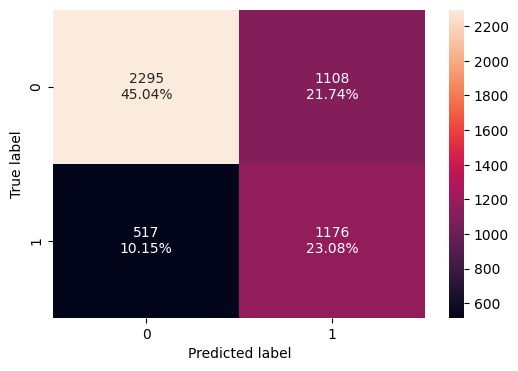


dtree  Training Performance


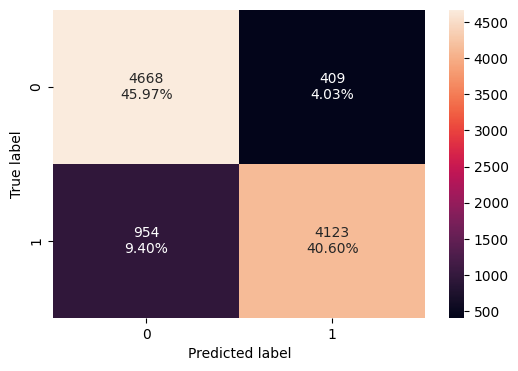


dtree  Validation Performance


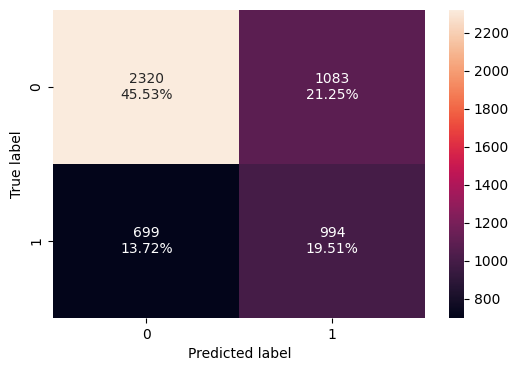

In [107]:
#Set model performance computation for Undersampled Data
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))


# Setting number of splits equal to 5
kfold = StratifiedKFold(
n_splits=5, shuffle=True, random_state=1
)
#loop through all policy flags
results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

print("\n" "Cross-Validation Performance of training set:" "\n")
# loop through all models to get the mean cross validated score
for name, model in models:
  scoring="f1"
  cv_result = cross_val_score(
  estimator=model, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
  )
  results.append(cv_result)
  names.append(name)
  print("{}: {}".format(name, cv_result.mean()))
print("\n" "Performance of validation set:" "\n")
for name, model in models:
  model.fit(X_train_un, y_train_un)
  scores = f1_score(y_val, model.predict(X_val))
  score.append(scores)
  print("{}: {}".format(name, scores))

# Plotting boxplots for CV scores of all models defined above for training set
print("\nTraining and Validation Performance Difference:\n")
i=0
for name,model in models:
  difference = score[i] - results[i].mean()
  print("{}, Difference: {:.4f}".format(name, difference))
  i=i+1
fig = plt.figure()
fig.suptitle("Algorithm Comparison for training set")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()
# Plotting barcharts for CV scores of all models defined above for validation set
fig = plt.figure()
sns.barplot(x=names,y=score,palette='viridis')
plt.title("Algorithm Comparison for validation set")
plt.show()


#Collate all accuracy scores for all models in one table for quick and easy comparison
dir_train={}
dir_val={}
i=[]
for name, model in models:
  #print("\n" + name," Training Performance")
  dir_train[name] = pd.DataFrame(model_performance_classification_sklearn(model, X_train_un, y_train_un))
  #print("\n" + name," Validation Performance")
  dir_val[name] = (model_performance_classification_sklearn(model, X_val, y_val))
  i.append(name)
df_train=pd.concat([dir_train[name] for name in dir_train.keys()],ignore_index=True)
df_val=pd.concat([dir_val[name] for name in dir_val.keys()],ignore_index=True)
df_train.index=i
df_val.index=i
print("Training set performance\n",df_train,"\n\nValidation set Performance\n", df_val)

#Plot confusion matrix for all models for both training and validation sets
for name, model in models:
  print("\n" + name," Training Performance")
  (confusion_matrix_sklearn(model, X_train_un, y_train_un))
  plt.show()
  print("\n" + name," Validation Performance")
  (confusion_matrix_sklearn(model, X_val, y_val))
  plt.show()

##Observations
1. Undersampling based models are performing marginally better than the oversampling models in terms of their f1 scores.
2.  GBM, Adaboost, XGBoost continue to be outperforming the other models.
3. Validation performance is much lower than training performance for bagging, random forest, and decision tree models.  Shows that these models are trying to overfit the training data.  For GBM, Adaboost, and XGBoost, validation and training performance are closer, showing that these models are generalizing well.
4.  Overall, GBM undersampled is the best model so far for f1 maximization.
5. Since other models could also perform better in hyperparameter tuning, let us try to perform tuning for all the models.

# **Model Performance Improvement**
#**Hyperparameter Tuning**

Let us first start with hyperparameter tuning for standard models (without oversampling or undersampling)
**Standard Model**

Also, we shall use randomized cross validation to save computation time while still getting optimized enough results.

In [109]:
#Start with hyperparameter tuning of standard dataset without oversampling or undersampling
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
#results = []  # Empty list to store all model's CV scores
  #names = []  # Empty list to store name of the models
  #score = []

# loop through all models to get the oversampled models tuned and check their performance
for name, model in models:
  if name == "Bagging":
    param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
    }
  else :
    if name == "Random forest":
      param_grid = {
      "n_estimators": [50,110,25],
      "min_samples_leaf": np.arange(1, 4),
      "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
      "max_samples": np.arange(0.4, 0.7, 0.1)
      }
    else:
      if name == "GBM":
        param_grid = {
        "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
        "n_estimators": np.arange(50,110,25),
        "learning_rate": [0.01,0.1,0.05],
        "subsample":[0.7,0.9],
        "max_features":[0.5,0.7,1],
        }
      else:
        if name == "Adaboost":
          param_grid = {
          "n_estimators": np.arange(50,110,25),
          "learning_rate": [0.01,0.1,0.05],
          "estimator": [
          DecisionTreeClassifier(max_depth=2, random_state=1),
          DecisionTreeClassifier(max_depth=3, random_state=1),
          ],
          }
        else:
          if name == "Xgboost":
            param_grid= {
            'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
            }
          else :
            if name == "dtree":
              param_grid = {
              'max_depth': np.arange(2,6),
              'min_samples_leaf': [1, 4, 7],
              'max_leaf_nodes' : [10, 15],
              'min_impurity_decrease': [0.0001,0.001]
              }
  scorer = metrics.make_scorer(metrics.f1_score)
  #Calling RandomizedSearchCV
  randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)
  #Fitting parameters in RandomizedSearchCV
  randomized_cv.fit(X_train, y_train)
  print("Best parameters for model {} are {} with CV score={}:" .format(name,randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters for model Bagging are {'n_estimators': 30, 'max_samples': 0.8, 'max_features': 0.9} with CV score=0.5223476517793141:
Best parameters for model Random forest are {'n_estimators': 110, 'min_samples_leaf': np.int64(3), 'max_samples': np.float64(0.6), 'max_features': 'sqrt'} with CV score=0.5597200241546343:
Best parameters for model GBM are {'subsample': 0.9, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.5563600768377699:
Best parameters for model Adaboost are {'n_estimators': np.int64(100), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.5503050310531454:
Best parameters for model Xgboost are {'subsample': 0.9, 'scale_pos_weight': 2, 'n_estimators': np.int64(100), 'learning_rate': 0.1, 'gamma': 1} with CV score=0.6150257354399857:
Best parameters for model dtree are {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_le

##Observations
1. XGBoost training f1 score is the only one that comes close to the best that we had so far (GBM undersampled f1 score).
2. All the other models training f1 score is less than the validation score of undersampled untuned models.  Hence, no point investigating them further.

Let us investigate XGBoost from here for generalized performance and validation f1 score.

In [110]:
tuned_xgb = XGBClassifier(
    n_estimators = 100,
            scale_pos_weight = 2,
            learning_rate = 0.1,
            gamma = 1,
            subsample  = 0.9
)
tuned_xgb.fit(X_train, y_train)
# Checking model's performance on training set
xgb_train = model_performance_classification_sklearn(tuned_xgb, X_train, y_train)
print("Training")
print(xgb_train)
# Checking model's performance on validation set
xgb_val = model_performance_classification_sklearn(tuned_xgb, X_val, y_val)
print("Validation")
print(xgb_val)



Training
   Accuracy  Recall  Precision    F1
0     0.747   0.710      0.600 0.651
Validation
   Accuracy  Recall  Precision    F1
0     0.709   0.680      0.550 0.608


##Observations:
1. This is one of the high scores for f1 so far.  We can compare this later with the oversampled and undersampled F1 scores for different models.  Overall, the model is generalizing well.  It has one of the highest recall and precision scores as well.  This could be a contender for one of the best models so far.

##**Hyperparameter tuning for oversampled models**



In [112]:
# define a function to fit all models one by one

def fit_model(name, model, param_grid, X, y):
  # f1 scoring used to compare parameter combinations
  scorer = metrics.make_scorer(metrics.f1_score)
  #Calling RandomizedSearchCV
  randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)
  #Fitting parameters in RandomizedSearchCV
  randomized_cv.fit(X, y)
  print("Best parameters for model {} are {} with CV score={}:" .format(name,randomized_cv.best_params_,randomized_cv.best_score_))

In [113]:
#Let us run the models again with oversampled data
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the oversampled models tuned and check their performance
for name, model in models:
  if name == "Bagging":
    param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
    }
  else :
    if name == "Random forest":
      param_grid = {
      "n_estimators": [50,110,25],
      "min_samples_leaf": np.arange(1, 4),
      "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
      "max_samples": np.arange(0.4, 0.7, 0.1)
      }
    else:
      if name == "GBM":
        param_grid = {
        "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
        "n_estimators": np.arange(50,110,25),
        "learning_rate": [0.01,0.1,0.05],
        "subsample":[0.7,0.9],
        "max_features":[0.5,0.7,1],
        }
      else:
        if name == "Adaboost":
          param_grid = {
          "n_estimators": np.arange(50,110,25),
          "learning_rate": [0.01,0.1,0.05],
          "estimator": [
          DecisionTreeClassifier(max_depth=2, random_state=1),
          DecisionTreeClassifier(max_depth=3, random_state=1),
          ],
          }
        else:
          if name == "Xgboost":
            param_grid= {
            'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
            }
          else :
            if name == "dtree":
              param_grid = {
              'max_depth': np.arange(2,6),
              'min_samples_leaf': [1, 4, 7],
              'max_leaf_nodes' : [10, 15],
              'min_impurity_decrease': [0.0001,0.001]
              }
  fit_model(name, model, param_grid, X_train_over, y_train_over)

Best parameters for model Bagging are {'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.8} with CV score=0.7542105598686268:
Best parameters for model Random forest are {'n_estimators': 110, 'min_samples_leaf': np.int64(1), 'max_samples': np.float64(0.4), 'max_features': 'sqrt'} with CV score=0.7532151573562148:
Best parameters for model GBM are {'subsample': 0.7, 'n_estimators': np.int64(50), 'max_features': 1, 'learning_rate': 0.01, 'init': DecisionTreeClassifier(random_state=1)} with CV score=0.739517720599822:
Best parameters for model Adaboost are {'n_estimators': np.int64(75), 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.7258975999834876:
Best parameters for model Xgboost are {'subsample': 0.7, 'scale_pos_weight': 2, 'n_estimators': np.int64(100), 'learning_rate': 0.1, 'gamma': 1} with CV score=0.7530872334200203:
Best parameters for model dtree are {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_l

##Observations
1. Bagging, Randomforest, amd XGBoost models show high f1 scores for training set after hyperparameter tuning with oversampled data.
2.  However, these could simply be overfitting training data as was seen in the modeling with the standard data set.  Need to cross check with validation data to gauge real performance of these models.
3.  Let us proceed with cross-checking all the models against their training set performance.

In [114]:
#Use the best parameters to get the tuned model
#Bagging
tuned_over_bag = BaggingClassifier(
    random_state=1,
    n_estimators=70,
    max_samples=0.8,
    max_features=0.8
)
tuned_over_bag.fit(X_train_over, y_train_over)

BaggingClassifier(max_features=0.8, max_samples=0.8, n_estimators=70,
                  random_state=1)

In [115]:
#Random Forest
tuned_over_rand = RandomForestClassifier(
    random_state=1,
    n_estimators=110,
    min_samples_leaf=1,
    max_features='sqrt',
    max_samples=0.4
)
tuned_over_rand.fit(X_train_over, y_train_over)

RandomForestClassifier(max_samples=0.4, n_estimators=110, random_state=1)

In [116]:
#GBM
tuned_over_gbm = GradientBoostingClassifier(
    random_state=1,
    learning_rate=0.01,
    n_estimators=50,
    subsample=0.7,
    max_features=1.0,
    init=DecisionTreeClassifier(random_state=1)
)
tuned_over_gbm.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=DecisionTreeClassifier(random_state=1),
                           learning_rate=0.01, max_features=1.0,
                           n_estimators=50, random_state=1, subsample=0.7)

In [117]:
#Adaboost
tuned_over_ada = AdaBoostClassifier(
    n_estimators =75,
    learning_rate= 0.05,
    estimator= DecisionTreeClassifier(max_depth=3, random_state=1),
        random_state=1,
)
tuned_over_ada.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.05, n_estimators=75, random_state=1)

In [118]:
#XGB
tuned_over_xgb = XGBClassifier(
    n_estimators = 100,
            scale_pos_weight = 2,
            learning_rate = 0.1,
            gamma = 1,
            subsample  = 0.7
)
tuned_over_xgb.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [119]:
#Decision Tree
tuned_over_dtree = DecisionTreeClassifier(
    max_depth = 2,
    min_samples_leaf = 1,
    max_leaf_nodes = 10,
    min_impurity_decrease = 0.0001,
    random_state=1
)
tuned_over_dtree.fit(X_train_over, y_train_over)

DecisionTreeClassifier(max_depth=2, max_leaf_nodes=10,
                       min_impurity_decrease=0.0001, random_state=1)

In [120]:
# Checking model's performance on training set
bag_over_train = model_performance_classification_sklearn(tuned_over_bag, X_train_over, y_train_over)
rand_over_train = model_performance_classification_sklearn(tuned_over_rand, X_train_over, y_train_over)
gbm_over_train = model_performance_classification_sklearn(tuned_over_gbm, X_train_over, y_train_over)
ada_over_train = model_performance_classification_sklearn(tuned_over_ada, X_train_over, y_train_over)
xgb_over_train = model_performance_classification_sklearn(tuned_over_xgb, X_train_over, y_train_over)
dtree_over_train = model_performance_classification_sklearn(tuned_over_dtree, X_train_over, y_train_over)

# training performance comparison
models_over_train_comp_df = pd.concat(
    [
        bag_over_train.T,
        rand_over_train.T,
        gbm_over_train.T,
        ada_over_train.T,
        xgb_over_train.T,
        dtree_over_train.T,
    ],
    axis=1,
)
models_over_train_comp_df.columns = [
    "Bagging trained with Oversampled data",
    "Random Forest trained with Oversampled data",
    "Gradient Boost trained with Oversampled data",
    "Ada Boost trained with Oversampled data",
    "XGBoost trained with Oversampled data",
    "Decision Tree trained with Oversampled data",
]
print("Training performance comparison:")
models_over_train_comp_df

Training performance comparison:


,Bagging trained with Oversampled data,Random Forest trained with Oversampled data,Gradient Boost trained with Oversampled data,Ada Boost trained with Oversampled data,XGBoost trained with Oversampled data,Decision Tree trained with Oversampled data
Accuracy,0.838,0.844,0.861,0.704,0.734,0.663
Recall,0.856,0.877,0.900,0.788,0.927,0.920
Precision,0.825,0.823,0.835,0.674,0.668,0.608
F1,0.841,0.849,0.866,0.727,0.777,0.732


In [121]:
# Checking model's performance on validation set
bag_over_val = model_performance_classification_sklearn(tuned_over_bag, X_val, y_val)
rand_over_val = model_performance_classification_sklearn(tuned_over_rand, X_val, y_val)
gbm_over_val = model_performance_classification_sklearn(tuned_over_gbm, X_val, y_val)
ada_over_val = model_performance_classification_sklearn(tuned_over_ada, X_val, y_val)
xgb_over_val = model_performance_classification_sklearn(tuned_over_xgb, X_val, y_val)
dtree_over_val = model_performance_classification_sklearn(tuned_over_dtree, X_val, y_val)

# validation performance comparison
models_over_val_comp_df = pd.concat(
    [
        bag_over_val.T,
        rand_over_val.T,
        gbm_over_val.T,
        ada_over_val.T,
        xgb_over_val.T,
        dtree_over_val.T,
    ],
    axis=1,
)
models_over_val_comp_df.columns = [
    "Bagging trained with Oversampled data",
    "Random Forest trained with Oversampled data",
    "Gradient Boost trained with Oversampled data",
    "Ada Boost trained with Oversampled data",
    "XGBoost trained with Oversampled data",
    "Decision Tree trained with Oversampled data",
]
print("Validation performance comparison:")
models_over_val_comp_df

Validation performance comparison:


,Bagging trained with Oversampled data,Random Forest trained with Oversampled data,Gradient Boost trained with Oversampled data,Ada Boost trained with Oversampled data,XGBoost trained with Oversampled data,Decision Tree trained with Oversampled data
Accuracy,0.689,0.681,0.654,0.665,0.619,0.566
Recall,0.627,0.648,0.611,0.768,0.850,0.890
Precision,0.527,0.516,0.483,0.498,0.460,0.427
F1,0.573,0.574,0.540,0.604,0.597,0.577


##Observations:
1. Only Adaboost validation score for F1 comes close to high score.
2. All of the models have their validation scores much smaller than the training scores.  Hence, the models seem to be overfitting.
3. The best score here is still marginally worse than the one for Tuned XGBoost with no oversampling or undersamping performed.
4.  Thus, the two best samples so far are Tuned XGBoost with Base Data, and Tuned Adaboost with oversampled data.

##**Hyperparameter tuning for undersampled data**

In [122]:
#Let us run the models again with undersampled data
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the undersampled models tuned and check their performance
for name, model in models:
  if name == "Bagging":
    param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
    }
  else :
    if name == "Random forest":
      param_grid = {
      "n_estimators": [50,110,25],
      "min_samples_leaf": np.arange(1, 4),
      "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
      "max_samples": np.arange(0.4, 0.7, 0.1)
      }
    else:
      if name == "GBM":
        param_grid = {
        "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
        "n_estimators": np.arange(50,110,25),
        "learning_rate": [0.01,0.1,0.05],
        "subsample":[0.7,0.9],
        "max_features":[0.5,0.7,1],
        }
      else:
        if name == "Adaboost":
          param_grid = {
          "n_estimators": np.arange(50,110,25),
          "learning_rate": [0.01,0.1,0.05],
          "estimator": [
          DecisionTreeClassifier(max_depth=2, random_state=1),
          DecisionTreeClassifier(max_depth=3, random_state=1),
          ],
          }
        else:
          if name == "Xgboost":
            param_grid= {
            'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
            }
          else :
            if name == "dtree":
              param_grid = {
              'max_depth': np.arange(2,6),
              'min_samples_leaf': [1, 4, 7],
              'max_leaf_nodes' : [10, 15],
              'min_impurity_decrease': [0.0001,0.001]
              }
  fit_model(name, model, param_grid, X_train_un, y_train_un)

Best parameters for model Bagging are {'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.7} with CV score=0.6877496265459652:
Best parameters for model Random forest are {'n_estimators': 25, 'min_samples_leaf': np.int64(3), 'max_samples': np.float64(0.5), 'max_features': 'sqrt'} with CV score=0.7047815217372828:
Best parameters for model GBM are {'subsample': 0.7, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7054983575128582:
Best parameters for model Adaboost are {'n_estimators': np.int64(75), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.7091326710753008:
Best parameters for model Xgboost are {'subsample': 0.9, 'scale_pos_weight': 2, 'n_estimators': np.int64(75), 'learning_rate': 0.1, 'gamma': 3} with CV score=0.7298362589181153:
Best parameters for model dtree are {'min_samples_leaf': 1, 'min_impurity_decrease': 0.0001, 'max_leaf

In [123]:
#Use the best parameters to get the tuned model
#Bagging
tuned_under_bag = BaggingClassifier(
    random_state=1,
    n_estimators=70,
    max_samples=0.8,
    max_features=0.7
)
tuned_under_bag.fit(X_train_un, y_train_un)

BaggingClassifier(max_features=0.7, max_samples=0.8, n_estimators=70,
                  random_state=1)

In [124]:
#Random Forest
tuned_under_rand = RandomForestClassifier(
    random_state=1,
    n_estimators=25,
    min_samples_leaf=3,
    max_features='sqrt',
    max_samples=0.5
)
tuned_under_rand.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.5, min_samples_leaf=3, n_estimators=25,
                       random_state=1)

In [125]:
#GBM
tuned_under_gbm = GradientBoostingClassifier(
    random_state=1,
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.7,
    max_features=0.5,
    init=AdaBoostClassifier(random_state=1)
)
tuned_under_gbm.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.5, random_state=1,
                           subsample=0.7)

In [126]:
#Adaboost
tuned_under_ada = AdaBoostClassifier(
    n_estimators =75,
    learning_rate= 0.1,
    estimator= DecisionTreeClassifier(max_depth=3, random_state=1),
        random_state=1,
)
tuned_under_ada.fit(X_train_un, y_train_un)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=75, random_state=1)

In [127]:
#XGB
tuned_under_xgb = XGBClassifier(
    n_estimators = 75,
            scale_pos_weight = 2,
            learning_rate = 0.1,
            gamma = 3,
            subsample  = 0.9
)
tuned_under_xgb.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=75,
              n_jobs=None, num_parallel_tree=None, ...)

In [128]:
#Decision Tree
tuned_under_dtree = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_leaf = 1,
    max_leaf_nodes = 15,
    min_impurity_decrease = 0.0001,
    random_state=1
)
tuned_under_dtree.fit(X_train_un, y_train_un)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.0001, random_state=1)

In [134]:
# Checking model's performance on training set
bag_under_train = model_performance_classification_sklearn(tuned_under_bag, X_train_un, y_train_un)
rand_under_train = model_performance_classification_sklearn(tuned_under_rand, X_train_un, y_train_un)
gbm_under_train = model_performance_classification_sklearn(tuned_under_gbm, X_train_un, y_train_un)
ada_under_train = model_performance_classification_sklearn(tuned_under_ada, X_train_un, y_train_un)
xgb_under_train = model_performance_classification_sklearn(tuned_under_xgb, X_train_un, y_train_un)
dtree_under_train = model_performance_classification_sklearn(tuned_under_dtree, X_train_un, y_train_un)

# training performance comparison
models_under_train_comp_df = pd.concat(
    [
        bag_under_train,
        rand_under_train,
        gbm_under_train,
        ada_under_train,
        xgb_under_train,
        dtree_under_train,
    ],
    ignore_index=True,
    )
labels = [
    "Bagging Undersampled",
    "Random Forest Undersampled",
    "Gradient Boost Undersampled",
    "Ada Boost Undersampled",
    "XGBoost Undersampled",
    "Decision Tree Undersampled",
]
models_under_train_comp_df.index = labels
print("Training performance comparison:")
print(models_under_train_comp_df)

# Checking model's performance on validation set
bag_under_val = model_performance_classification_sklearn(tuned_under_bag, X_val, y_val)
rand_under_val = model_performance_classification_sklearn(tuned_under_rand, X_val, y_val)
gbm_under_val = model_performance_classification_sklearn(tuned_under_gbm, X_val, y_val)
ada_under_val = model_performance_classification_sklearn(tuned_under_ada, X_val, y_val)
xgb_under_val = model_performance_classification_sklearn(tuned_under_xgb, X_val, y_val)
dtree_under_val = model_performance_classification_sklearn(tuned_under_dtree, X_val, y_val)

# training performance comparison
models_under_val_comp_df = pd.concat(
    [
        bag_under_val,
        rand_under_val,
        gbm_under_val,
        ada_under_val,
        xgb_under_val,
        dtree_under_val,
    ],
    ignore_index=True,
    )

models_under_val_comp_df.index = labels
print("Validation performance comparison:")
print(models_under_val_comp_df)

Training performance comparison:
                             Accuracy  Recall  Precision    F1
Bagging Undersampled            0.817   0.809      0.822 0.815
Random Forest Undersampled      0.756   0.735      0.767 0.751
Gradient Boost Undersampled     0.711   0.706      0.712 0.709
Ada Boost Undersampled          0.706   0.718      0.702 0.710
XGBoost Undersampled            0.687   0.902      0.631 0.742
Decision Tree Undersampled      0.697   0.673      0.707 0.690
Validation performance comparison:
                             Accuracy  Recall  Precision    F1
Bagging Undersampled            0.683   0.685      0.517 0.589
Random Forest Undersampled      0.705   0.690      0.544 0.609
Gradient Boost Undersampled     0.698   0.714      0.534 0.611
Ada Boost Undersampled          0.691   0.727      0.525 0.609
XGBoost Undersampled            0.598   0.899      0.448 0.598
Decision Tree Undersampled      0.711   0.710      0.550 0.620


##Observations
1. 4 models here have performed better than any of the models before.  These are decision tree undersampled, GBM undersampled, Random Forest undersampled, and Adaboost undersampled.
2.  Each of these have F1 scores better than the previous best of 0.604 for Tuned Adaboost for oversampled data, and Tuned XGBoost for Base Data.
3.  The best performing model from all of these has turned out to be the decision tree undersampled.  This model is not only providing highest F1 score thus far; it is also generalizing well.  The training and validation f1 scores are quite close for this model, showcasing no overfitting.

##**Final Model Comparison for best models**

In [137]:
# Model training performance comparison

final_models_train_comp_df = pd.concat(
    [
        xgb_train.T,
        rand_under_train.T,
        dtree_under_train.T,
    ],
    axis=1,
)
final_models_train_comp_df.columns = [
    "XGBoost trained with Base data",
    "Random Forest trained with Undersampled data",
    "Decision trained with Undersampled data",
]
print("Training performance comparison:")
final_models_train_comp_df

Training performance comparison:


,XGBoost trained with Base data,Random Forest trained with Undersampled data,Decision trained with Undersampled data
Accuracy,0.747,0.756,0.697
Recall,0.710,0.735,0.673
Precision,0.600,0.767,0.707
F1,0.651,0.751,0.690


In [140]:
# Model validation performance comparison

final_models_val_comp_df = pd.concat(
    [
        xgb_val.T,
        rand_under_val.T,
        dtree_under_val.T,
    ],
    axis=1,
)
final_models_val_comp_df.columns = [
    "XGBoost trained with Base data",
    "Random Forest trained with Undersampled data",
    "Decision Tree trained with Undersampled data",
]
print("Validation performance comparison:")
final_models_val_comp_df

Validation performance comparison:


,XGBoost trained with Base data,Random Forest trained with Undersampled data,Decision Tree trained with Undersampled data
Accuracy,0.709,0.705,0.711
Recall,0.680,0.690,0.710
Precision,0.550,0.544,0.550
F1,0.608,0.609,0.620


##Observations
1. These three models have turned out to be the best so far.
2. Of these models, Random Forest has the biggest difference between training and validation data.  
3.  The tuned decision tree model for undersampled data has turned out to be unexpectedly highest scoring, while it was not scoring well in the previous iterations for Base Data, Oversampled data, or un-tuned hyperparameters.  Of the three models, it is also generalizing the best.

# **Final Model Selection**
Because of all the reasons mentioned above -
a) highest F1 score for validation and training data;
b) model that is generalizing well

We choose **Decision Tree model tuned with hyperparameters for undersampled data** as the final model.

##**Feature Importance**

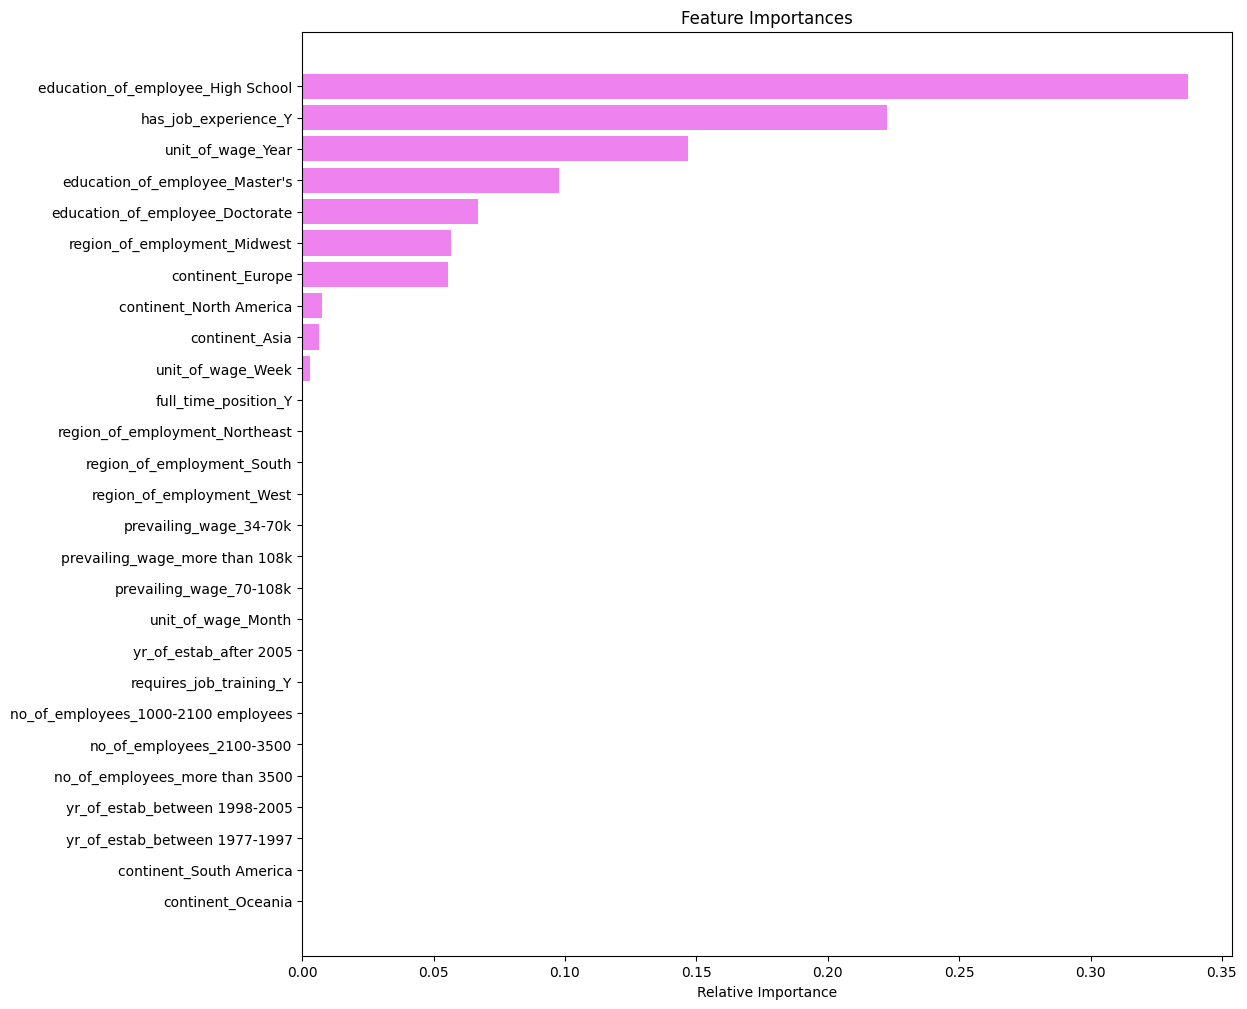

In [139]:
feature_names = X_train.columns
importances = tuned_under_dtree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##Observations
1. Education of applicant, Job Experience, Unit of Wage, Region of employment, and applicant home continent are the features with highest importance in visa decision, in decreasing order.
2.  Prevailing wage, full time versus part time, company size, and company age have almost no impact on the final decision.

##**Performance with test data**

In [141]:
#Use the final model to check performance on test data
dtree_under_test = model_performance_classification_sklearn(tuned_under_dtree, X_test, y_test)
print("Test performance:")
dtree_under_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.720,0.708,0.562,0.626


##Observations:
1. Even the test data has produced the best F1 score for this model.
2. Hence, this model is recommended for future predictions.

# **Actionable Insights and Recommendations**
1.  Since the model accuracy is still on the lower side, the results from the model should be used as a guide to help the human inspector take a decision.
2.  For all new applications, will need to convert data on their company age, company number of employees, and prevailing wage will need to categorized as per the bins finalized here.
3.  The visa officer should scrutinize applications with high school education, hourly wages, Latin American or North American applicants, with more detail as these are more likely to get screened out.
4.  Applications with applicants that are phD or Master's, applying from Europe, and have annual wages have higher chances of selection so they could be put through relatively lesser scrutiny.
5.  To improve accuracy compared to human screending, the dataset should be augmented with other data usually asked from the applicants, and reviewed by the inspectors..  For example, data linked to their home-country ties : their assets; as well as their security background, social media footprint and publications could be the other set of datapoints that could be added to the dataset.  These could help improve the accuracy of decision.
6.  Depending on the adminstration's philosophy, they may decide it is more important to reduce false positives or false negatives.   In other words, they may want only sure-shot visa applicants to progress to manual scrutiny (high recall), or they may want most people to get a hearing if the machine screens them out - which is about reducing false positives (high precision).  Thus, one could argue for high precision or recall as the main objective instead of high f1 scores.  In those cases, these models should be re-run depending upon what score the context asks to maximize.
7.  We utilized Randomsearch cross validation due to paucity of time.  However, ideally one should check with Gridsearch CV to ensure better hyperparameter tuning and a better fit of the models.  




*   



___